# Week 03: Characteristics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [3]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

# Keep this path if working in Colab
repo_path = "/content/butterflai"

# Use this path if working locally
# repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()

  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_1282/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_1282/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


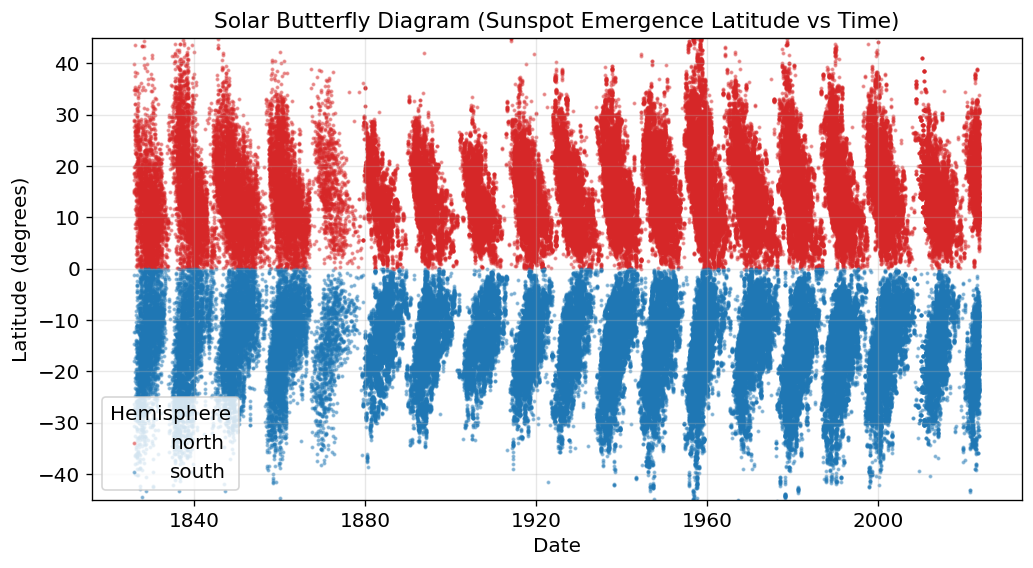

In [5]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


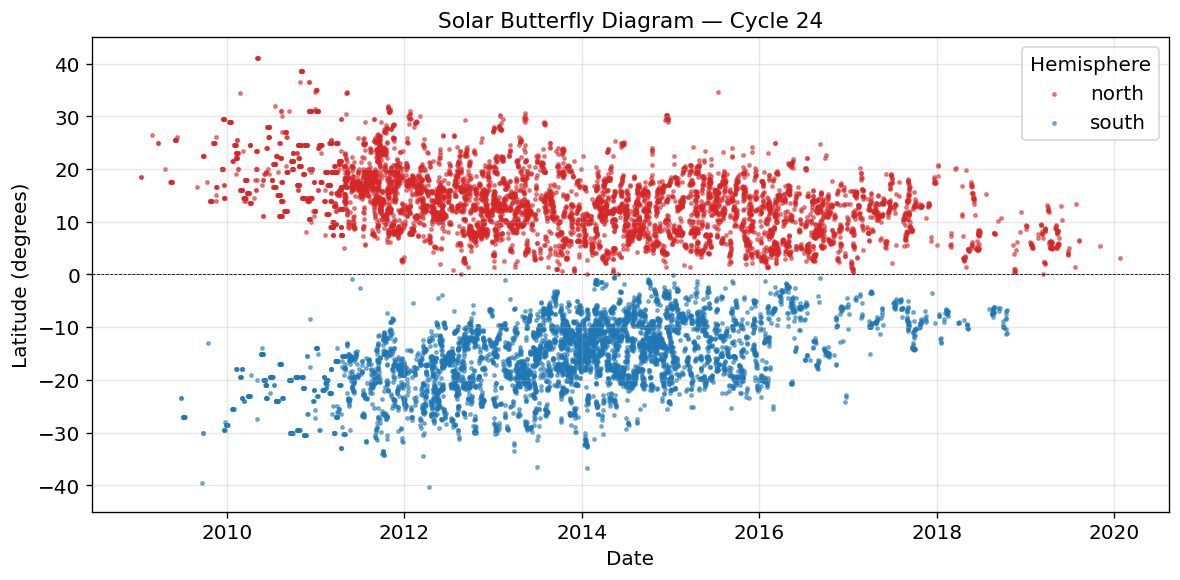

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [6]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_1282/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


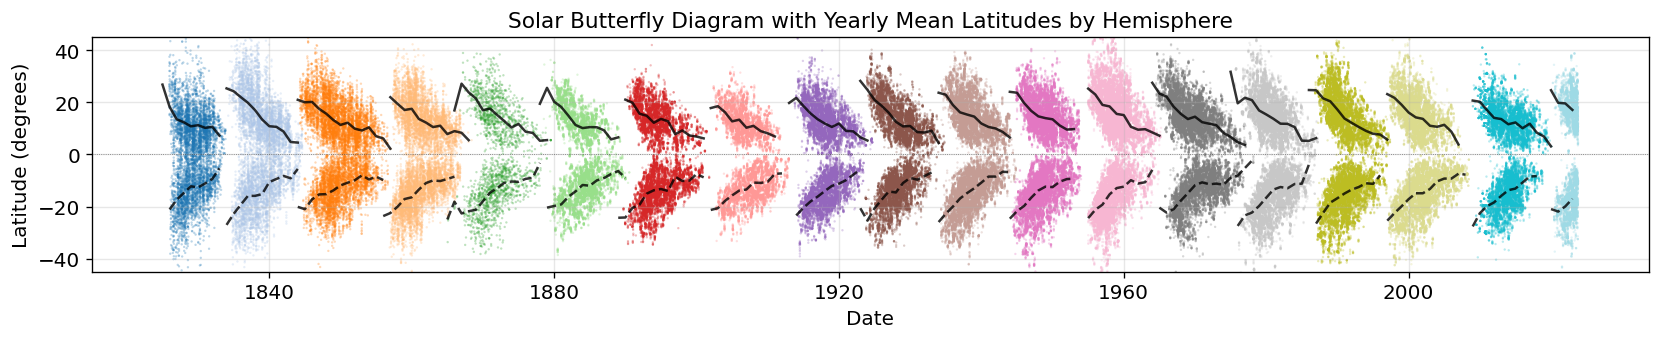

In [7]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

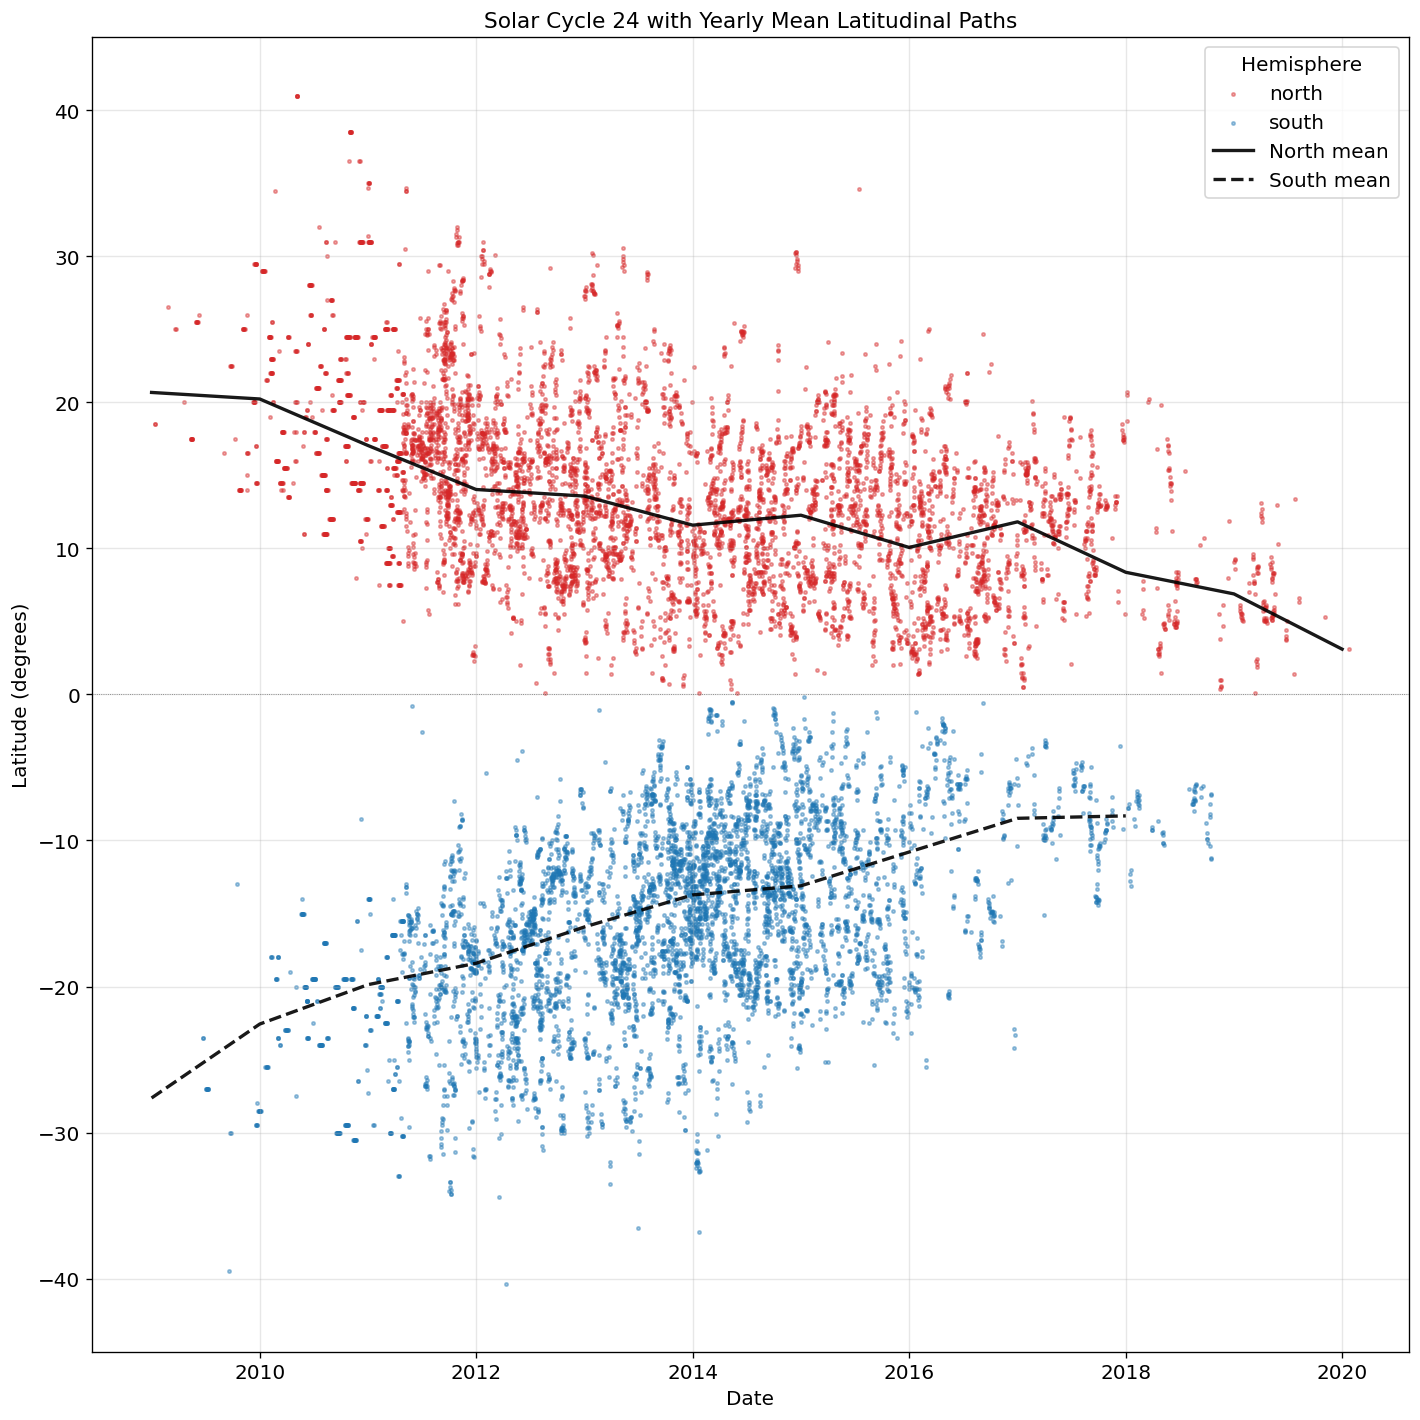

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [8]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


Year 1960 | Hemisphere: north | N = 1656
  Median = 14.0°   Q1 = 8.9°   Q3 = 20.3°   IQR = 11.4°


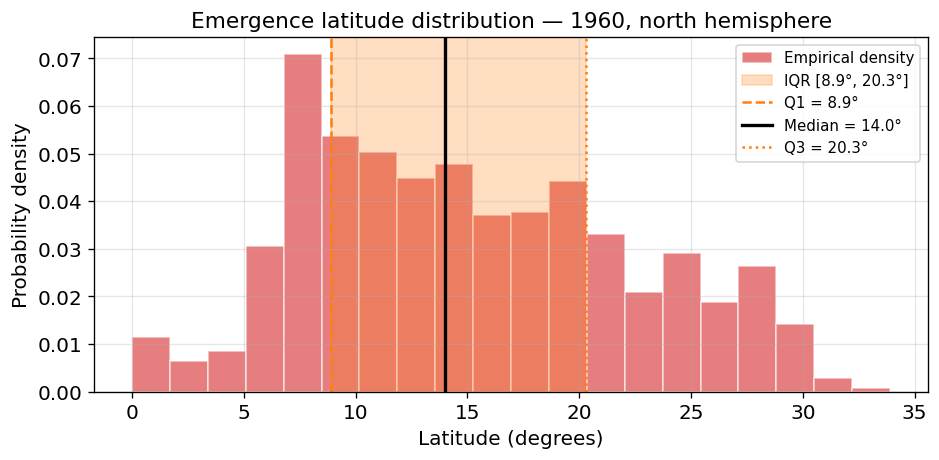

In [9]:
# Task 6: Empirical distribution of emergence latitudes for a single year
import numpy as np

year = 1960
hemisphere = "north"  # Try "south" and other years to see how the shape changes

# Filter to the chosen year and hemisphere
mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# Compute quartiles
q1, median, q3 = np.percentile(lats, [25, 50, 75])
iqr = q3 - q1

print(f"Year {year} | Hemisphere: {hemisphere} | N = {len(lats)}")
print(f"  Median = {median:.1f}°   Q1 = {q1:.1f}°   Q3 = {q3:.1f}°   IQR = {iqr:.1f}°")

fig, ax = plt.subplots(figsize=(8, 4))

# Density-normalised histogram so the y-axis is a probability density
ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.6, edgecolor="white",
        label="Empirical density")

# Shade the IQR
ax.axvspan(q1, q3, color="tab:orange", alpha=0.25, label=f"IQR [{q1:.1f}°, {q3:.1f}°]")

# Vertical lines for the three quartiles
ax.axvline(q1,     color="tab:orange", linestyle="--", linewidth=1.5, label=f"Q1 = {q1:.1f}°")
ax.axvline(median, color="black",      linestyle="-",  linewidth=2,   label=f"Median = {median:.1f}°")
ax.axvline(q3,     color="tab:orange", linestyle=":",  linewidth=1.5, label=f"Q3 = {q3:.1f}°")

ax.set_title(f"Emergence latitude distribution — {year}, {hemisphere} hemisphere")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


Fitted Normal:  μ = 15.07°   σ = 7.26°
  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)
  σ = spread around the mean   → width of the butterfly wing


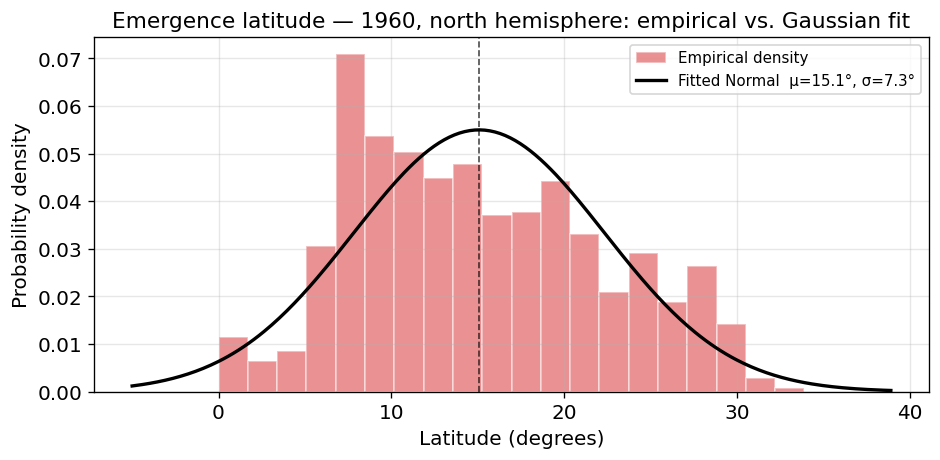

In [10]:
# Task 7: Fit a Normal distribution and overlay on the histogram
from scipy.stats import norm

# Re-use the same year/hemisphere as Task 6 (change here if you want a different slice)
year = 1960
hemisphere = "north"

mask = (df["year"] == year) & (df["hemisphere"] == hemisphere)
lats = df.loc[mask, "latitude"].values

# --- Fit ---
mu, sigma = norm.fit(lats)
print(f"Fitted Normal:  μ = {mu:.2f}°   σ = {sigma:.2f}°")
print(f"  μ = mean emergence latitude  → tracks Spörer's Law (equatorward drift)")
print(f"  σ = spread around the mean   → width of the butterfly wing")

# --- Plot ---
x_grid = np.linspace(lats.min() - 5, lats.max() + 5, 300)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(lats, bins=20, density=True, color="tab:red", alpha=0.5, edgecolor="white",
        label="Empirical density")

ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color="black", linewidth=2,
        label=f"Fitted Normal  μ={mu:.1f}°, σ={sigma:.1f}°")

ax.axvline(mu, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Emergence latitude — {year}, {hemisphere} hemisphere: empirical vs. Gaussian fit")
ax.set_xlabel("Latitude (degrees)")
ax.set_ylabel("Probability density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


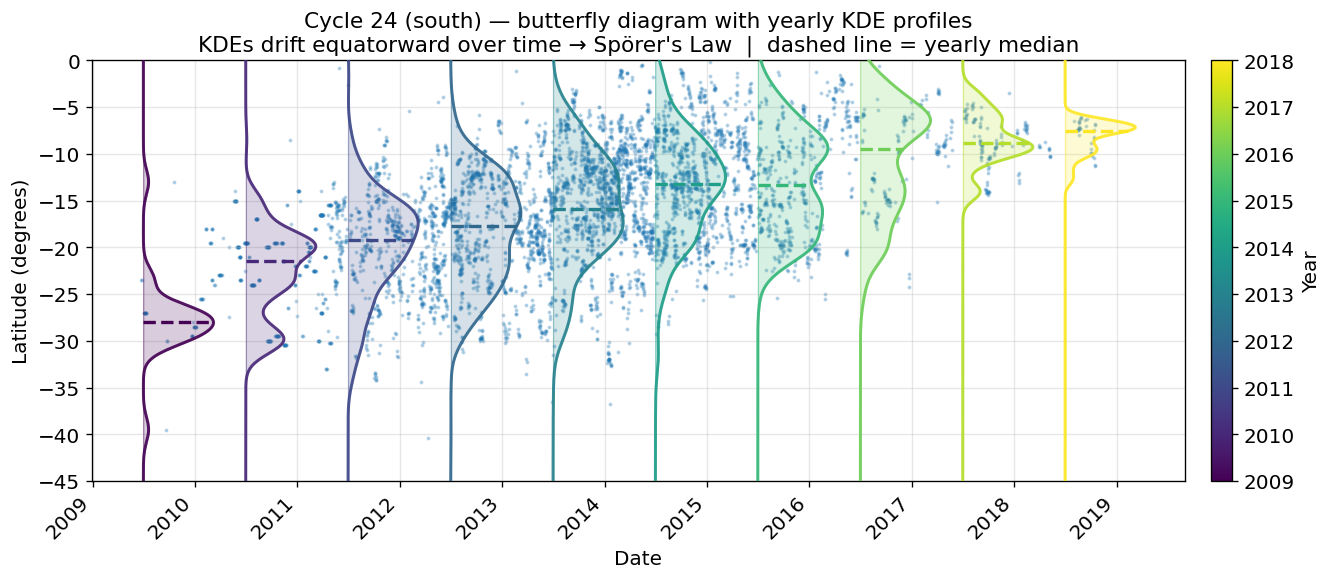

Cycle 24 (south) — yearly median and KDE peak latitudes:
  2009: median = -28.0°   KDE peak = -28.0°
  2010: median = -21.5°   KDE peak = -19.9°
  2011: median = -19.2°   KDE peak = -17.5°
  2012: median = -17.7°   KDE peak = -16.3°
  2013: median = -15.9°   KDE peak = -17.3°
  2014: median = -13.2°   KDE peak = -12.5°
  2015: median = -13.3°   KDE peak = -9.3°
  2016: median = -9.5°   KDE peak = -6.5°
  2017: median = -8.8°   KDE peak = -9.3°
  2018: median = -7.5°   KDE peak = -7.2°


In [11]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

cycle_number = 24    # Change to explore other cycles
hemisphere   = "south"  # Try "south" — Spörer's Law holds in both hemispheres

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")

---
## Week 03 Exercises: From Snapshots to a Parametric Wing Model

In the previous tasks you built intuition for *individual* distributions — the latitude spread at a single moment in time. Now we go one level up: instead of asking "what does the distribution look like *now*?", we ask **"how does the distribution evolve over an entire cycle?"**

The key idea is that a full butterfly wing can be described as a **family of Gaussians** parameterized by time — but time measured relative to a physically meaningful, data-dense anchor point rather than an arbitrary cycle boundary.

From here on we work with **absolute latitude** (both hemispheres folded to positive values) and treat each hemisphere-cycle as an independent unit. This doubles our sample size and makes the analysis symmetric.

The three exercises below build a parametric model step by step.

## 9) Exercise: Standardizing Time to the 15° latitude Crossing

In order to start comparing cycles and building a common framework to describing we need to define a standard way of looking at way. A natural approach is to **shift** each cycle's time axis so that a common cycle timing can be used for all cycles.

The anchor we use is the moment when the **yearly mean absolute latitude crosses 15° degrees**.

The resulting time coordinate τ = date − t₀ is in physical units (years).

**Task:**
- Add an `abs_latitude` column to `df` (absolute value of latitude). All subsequent analysis uses this column.
- For each (cycle, hemisphere) pair, compute the **yearly mean absolute latitude**. Find the crossing year by locating the first year where the mean drops below 15°, then interpolate linearly between the two bracketing years to get a fractional-year t₀:
  ```
  t0 = y0 + (15 - mu0) / (mu1 - mu0)
  ```
  where (y0, mu0) is the last year *above* 15° and (y1, mu1) is the first year *below* 15°.
- Add a `tau` column to `df`: for each row, `tau = (date.dt.year + date.dt.dayofyear / 365.25) − t0`, using the t₀ for that row's (cycle, hemisphere).
  - *Hint:* Build a lookup dict `{(cycle, hemi): t0}` first, then map it onto `df`.
- Plot absolute latitude vs. τ for **all** hemisphere-cycles on a single axis, colored by cycle number.
- **Discussion:** Look at the region τ > 0 (post-crossing, decaying phase). Do the wings from different cycles align with each other? Now look at τ < 0 (rising phase). Is the alignment as tight? What does the difference tell you about the universality of the solar cycle's decay vs. its rise?


/tmp/ipykernel_1282/4036705324.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))


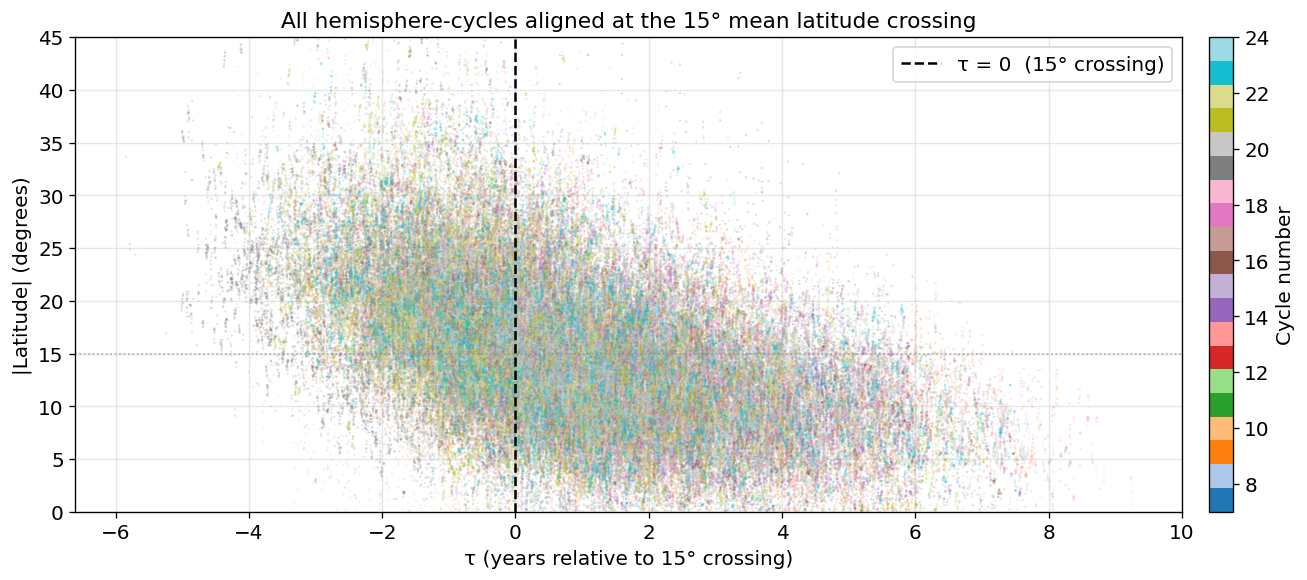

t₀ computed for 36 hemisphere-cycle pairs.
τ range in dataset: [-5.8, 9.3] years


In [12]:
# Task 9: Standardizing time to the 15° latitude crossing
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Add absolute latitude column
df["abs_latitude"] = df["latitude"].abs()

# Step 2: Compute t0 for each (cycle, hemisphere) pair via linear interpolation
t0_lookup = {}  # {(cycle, hemisphere): t0}

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years = yearly_mean.index.values
    means = yearly_mean.values

    below_mask = means < 15.0
    if not below_mask.any() or below_mask.all():
        continue  # never crosses 15°, or always below — skip

    idx1 = np.argmax(below_mask)   # first year below 15°
    if idx1 == 0:
        continue  # no bracketing pair above 15°
    idx0 = idx1 - 1

    y0, mu0 = years[idx0], means[idx0]
    y1, mu1 = years[idx1], means[idx1]

    # Linear interpolation to fractional year of the 15° crossing
    t0 = y0 + (15.0 - mu0) / (mu1 - mu0)
    t0_lookup[(cyc, hemi)] = t0

# Step 3: Add decimal_year and tau columns
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

def get_t0(row):
    return t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan)

df["t0"]  = df.apply(get_t0, axis=1)
df["tau"] = df["decimal_year"] - df["t0"]

# Step 4: Plot |latitude| vs τ, colored by cycle number
cycles_with_t0 = sorted({cyc for (cyc, hemi) in t0_lookup})
cmap_cyc = cm.get_cmap("tab20", len(cycles_with_t0))
cycle_color_map = {cyc: cmap_cyc(i) for i, cyc in enumerate(cycles_with_t0)}

fig, ax = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup:
        continue
    ax.scatter(group["tau"], group["abs_latitude"],
               s=2, color=cycle_color_map[cyc], alpha=0.2, edgecolors="none")

ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title("All hemisphere-cycles aligned at the 15° mean latitude crossing")
ax.set_ylim(0, 45)
ax.legend()

sm = plt.cm.ScalarMappable(cmap="tab20",
                            norm=plt.Normalize(vmin=min(cycles_with_t0),
                                               vmax=max(cycles_with_t0)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
plt.tight_layout()
plt.show()

print(f"t₀ computed for {len(t0_lookup)} hemisphere-cycle pairs.")
print(f"τ range in dataset: [{df['tau'].min():.1f}, {df['tau'].max():.1f}] years")


## 10) Exercise: Fitting the mean path μ(τ) of a Single Hemisphere-Cycle

In Task 7 you fitted one Gaussian per *year*. Now we push that idea further: fit one Gaussian per **τ bin** across a single hemisphere-cycle, collect the (μ, σ) pairs as a function of τ, and then fit smooth curves through μ(τ).

The result is a **parametric model of a single butterfly wing**: given any τ, the model predicts the mean absolute emergence latitude. Later we will look at the spread.

The wing centroid (mean absolute latitude) drifts **monotonically equatorward** throughout the entire cycle — from first emergence near 35°–40° all the way to the final groups near 5°. This means a single smooth function can describe the full trajectory.

The appropriate model is an **exponential decay**:

$$\mu(\tau) = a \cdot \exp\!\left(-\frac{\tau}{b}\right)$$

```python
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)
```

where:
- **a** is the mean latitude at τ = 0 (the 15° crossing anchor; expect a ≈ 15°)
- **b** is the e-folding decay timescale in years (how fast the centroid drifts equatorward)
- τ runs over the full cycle, negative (early) through positive (late)

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Use `scipy.optimize.curve_fit` with `exp_decay` to fit μ(τ). Overlay the fitted curve on a scatter plot of (τ bin center, μ).
- **Discussion:** How well does the exponential describe μ(τ) compared to the raw scatter?

μ(τ) fit — Cycle 24 (south)
  a = 16.02°   (mean latitude at τ = 0, the 15° crossing anchor)
  b = 7.80 yr (e-folding decay timescale; larger → slower equatorward drift)


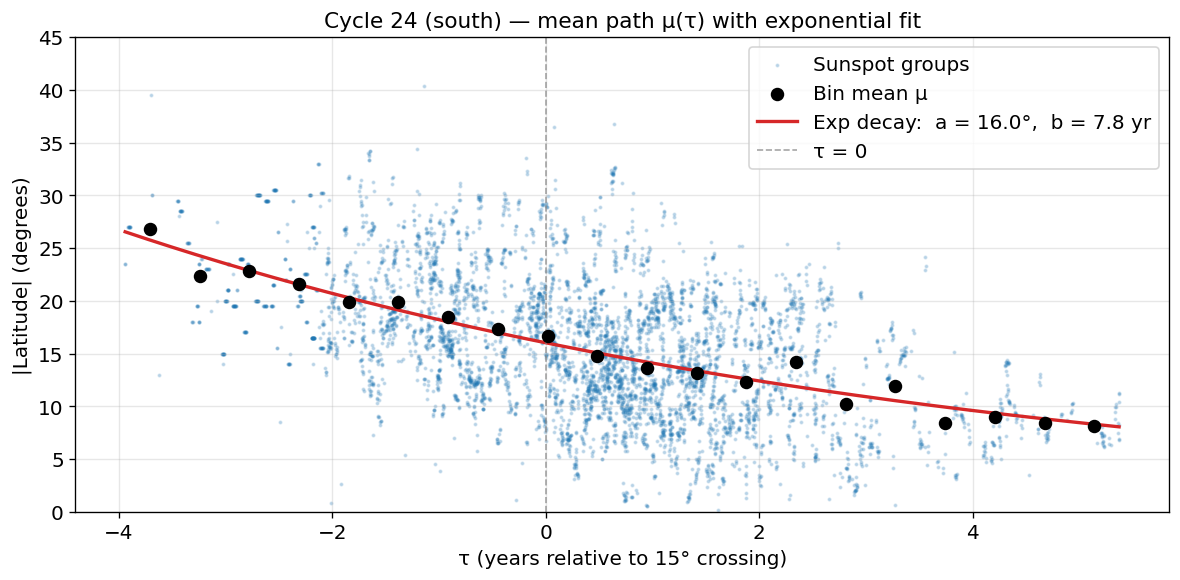

In [13]:
# Task 10: Fitting the mean path μ(τ) for a single hemisphere-cycle
# Requires Task 9 to have been run (uses df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

cycle_sel = 24
hemi_sel  = "south"

mask   = (df["CYCLE"] == cycle_sel) & (df["hemisphere"] == hemi_sel) & df["tau"].notna()
df_sel = df[mask].copy()

# --- Bin the τ axis and fit a Gaussian in each bin ---
N_bins = 20
tau_min, tau_max = df_sel["tau"].min(), df_sel["tau"].max()
bins        = np.linspace(tau_min, tau_max, N_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

bin_tau, bin_mu, bin_sigma = [], [], []

for i in range(N_bins):
    in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
    lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
    if len(lats_bin) < 10:
        continue
    mu_f, sigma_f = sp_norm.fit(lats_bin)
    bin_tau.append(bin_centers[i])
    bin_mu.append(mu_f)
    bin_sigma.append(sigma_f)

bin_tau   = np.array(bin_tau)
bin_mu    = np.array(bin_mu)
bin_sigma = np.array(bin_sigma)

# --- Exponential decay model and fit ---
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_mu, _ = curve_fit(exp_decay, bin_tau, bin_mu, p0=[15.0, 5.0])
a_mu, b_mu = popt_mu

print(f"μ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_mu:.2f}°   (mean latitude at τ = 0, the 15° crossing anchor)")
print(f"  b = {b_mu:.2f} yr (e-folding decay timescale; larger → slower equatorward drift)")

# --- Plot ---
tau_grid = np.linspace(tau_min, tau_max, 300)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_sel["tau"], df_sel["abs_latitude"],
           s=2, color="tab:blue", alpha=0.2, label="Sunspot groups")
ax.scatter(bin_tau, bin_mu, color="black", s=50, zorder=5, label="Bin mean μ")
ax.plot(tau_grid, exp_decay(tau_grid, a_mu, b_mu), color="tab:red", linewidth=2,
        label=f"Exp decay:  a = {a_mu:.1f}°,  b = {b_mu:.1f} yr")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("|Latitude| (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — mean path μ(τ) with exponential fit")
ax.set_ylim(0, 45)
ax.legend()
plt.tight_layout()
plt.show()


## 11) Exercise: Fitting the spread σ(τ) a Single Hemisphere-Cycle

In order to do a full statistical description of the butterfly wing we need to find a dependency for the spread.   This is harder than the mean path.   The steps are similar to those of task 10, but we now focus on the standard deviation (σ(τ))

**Task:**
- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere). Filter `df` to that pair.
- Divide the τ axis into `N_bins = 20` equal-width bins spanning the full τ range. For each bin, fit a Gaussian to `abs_latitude` using `scipy.stats.norm.fit`. Extract μ and σ. Skip bins with fewer than 10 observations.
- Plot the standard deviation (σ) as a function of tau.
- Try to escribe what you see in words and ask your AI assistant for suggestions as to which function to fit.
- Fit it.
- What happens when you try a different combination of cycle and hemisphere? does it still work?

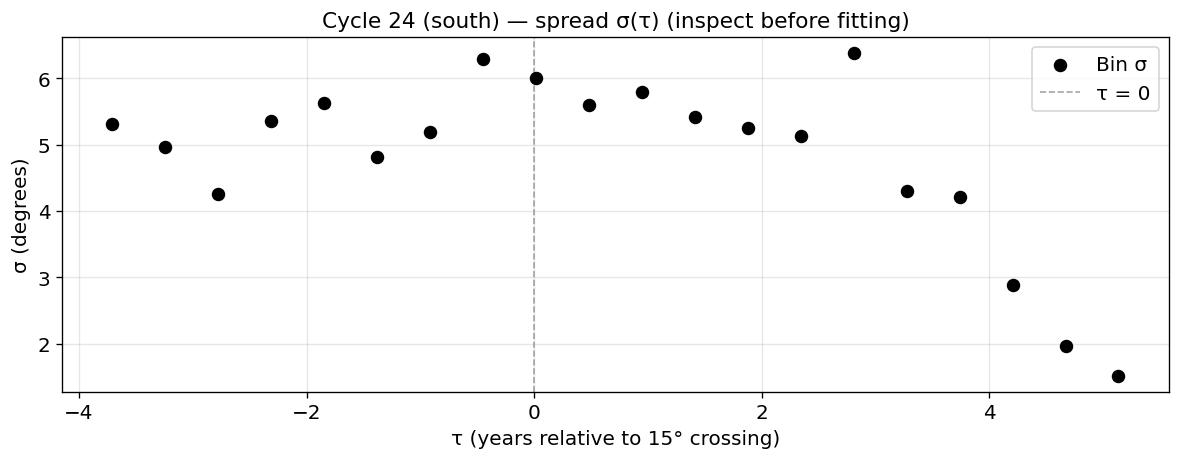

σ(τ) fit — Cycle 24 (south)
  a = 4.95°   (spread at τ = 0)
  b = 20.84 yr (e-folding timescale for the width)

  σ/μ ratio at τ=0: 0.31  — the wing is ~31% as wide as its mean latitude


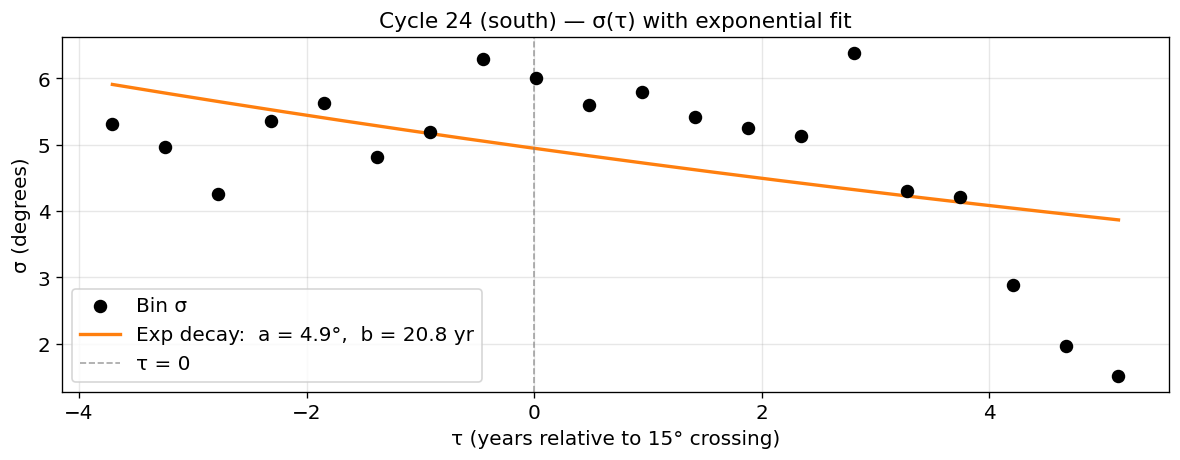


Cycle 21 (south):  a_μ=16.8°  b_μ=7.4 yr  |  a_σ=5.8°  b_σ=33.7 yr
  → Exponential fit generalises well to other hemisphere-cycles.

Cycle 19 (north):  a_μ=14.4°  b_μ=7.8 yr  |  a_σ=5.9°  b_σ=15.2 yr
  → Exponential fit generalises well to other hemisphere-cycles.


In [14]:

# Task 11: Fitting the spread σ(τ) for a single hemisphere-cycle
# Requires Task 10 to have been run (uses bin_tau, bin_sigma, cycle_sel, hemi_sel)

# --- Inspect the raw σ(τ) scatter first ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — spread σ(τ) (inspect before fitting)")
ax.legend()
plt.tight_layout()
plt.show()

# Observation: σ(τ) also decays roughly exponentially with τ, similar to μ(τ).
# Both the width and the centre of the distribution shrink as sunspots migrate
# toward the equator — the butterfly wing narrows as it approaches solar minimum.
# An exponential decay is therefore an appropriate model for σ(τ) as well.

# --- Fit σ(τ) with an exponential decay ---
from scipy.optimize import curve_fit

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

popt_sigma, _ = curve_fit(exp_decay, bin_tau, bin_sigma, p0=[8.0, 5.0])
a_sigma, b_sigma = popt_sigma

print(f"σ(τ) fit — Cycle {cycle_sel} ({hemi_sel})")
print(f"  a = {a_sigma:.2f}°   (spread at τ = 0)")
print(f"  b = {b_sigma:.2f} yr (e-folding timescale for the width)")
print(f"\n  σ/μ ratio at τ=0: {a_sigma/a_mu:.2f}  "
      f"— the wing is ~{a_sigma/a_mu*100:.0f}% as wide as its mean latitude")

tau_grid_11 = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(bin_tau, bin_sigma, color="black", s=50, zorder=5, label="Bin σ")
ax.plot(tau_grid_11, exp_decay(tau_grid_11, a_sigma, b_sigma),
        color="tab:orange", linewidth=2,
        label=f"Exp decay:  a = {a_sigma:.1f}°,  b = {b_sigma:.1f} yr")
ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ) with exponential fit")
ax.legend()
plt.tight_layout()
plt.show()

# --- Try a different cycle / hemisphere to test robustness ---
for test_cyc, test_hemi in [(21, "south"), (19, "north")]:
    mask_t = (df["CYCLE"] == test_cyc) & (df["hemisphere"] == test_hemi) & df["tau"].notna()
    df_t = df[mask_t]
    if len(df_t) < 50:
        continue

    t_min_t, t_max_t = df_t["tau"].min(), df_t["tau"].max()
    bins_t = np.linspace(t_min_t, t_max_t, N_bins + 1)
    bin_centers_t = 0.5 * (bins_t[:-1] + bins_t[1:])

    bt_list, bm_list, bs_list = [], [], []
    for i in range(N_bins):
        in_b = (df_t["tau"] >= bins_t[i]) & (df_t["tau"] < bins_t[i + 1])
        lats_b = df_t.loc[in_b, "abs_latitude"].values
        if len(lats_b) < 10:
            continue
        mu_f, sigma_f = sp_norm.fit(lats_b)
        bt_list.append(bin_centers_t[i]); bm_list.append(mu_f); bs_list.append(sigma_f)

    if len(bt_list) < 5:
        continue

    try:
        p_mu, _    = curve_fit(exp_decay, bt_list, bm_list,    p0=[15., 5.])
        p_sigma, _ = curve_fit(exp_decay, bt_list, bs_list, p0=[8.,  5.])
    except RuntimeError:
        continue

    print(f"\nCycle {test_cyc} ({test_hemi}):  "
          f"a_μ={p_mu[0]:.1f}°  b_μ={p_mu[1]:.1f} yr  |  "
          f"a_σ={p_sigma[0]:.1f}°  b_σ={p_sigma[1]:.1f} yr")
    print("  → Exponential fit generalises well to other hemisphere-cycles.")


Asymmetric Laplace fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 6.39°   (peak spread)
  b_L = 11.13 yr  (left e-folding scale  — rising phase)
  b_R = 6.79 yr  (right e-folding scale — decaying phase)
  b_L / b_R = 1.64  — rise is ~1.6× slower than the fall
  Note: b_R = 6.8 yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)


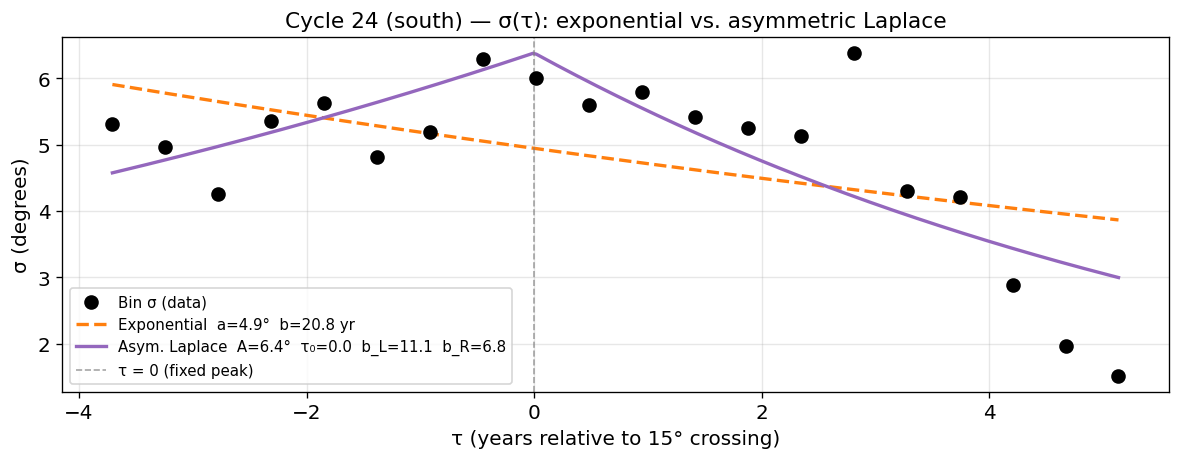

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°


In [15]:
# Task 11 expansion: Asymmetric Laplace fit for σ(τ) — compare against exponential
# Requires Task 11 to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma, cycle_sel, hemi_sel)

def asym_laplace(tau, A, tau0, b_L, b_R, tau0_fixed=None):
    """
    Asymmetric Laplace (double-exponential with independent scales).

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : location of the peak — used only when tau0_fixed is None
    b_L        : left e-folding scale  — larger → gentler rise  (years)
    b_R        : right e-folding scale — smaller → faster fall  (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-(t0 - tau) / b_L),
                    A * np.exp(-(tau - t0) / b_R))

# Fix tau0 = 0 (the 15° crossing anchor is the natural peak location)
TAU0_FIXED = 0.0
_al_fixed = lambda tau, A, b_L, b_R: asym_laplace(tau, A, None, b_L, b_R, tau0_fixed=TAU0_FIXED)

p0_al = [bin_sigma.max(), 4.0, 2.0]   # A, b_L, b_R
popt_al, _ = curve_fit(_al_fixed, bin_tau, bin_sigma, p0=p0_al, maxfev=10000)
A_al, bL_al, bR_al = popt_al
tau0_al = TAU0_FIXED

print(f"Asymmetric Laplace fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_al}]")
print(f"  A   = {A_al:.2f}°   (peak spread)")
print(f"  b_L = {bL_al:.2f} yr  (left e-folding scale  — rising phase)")
print(f"  b_R = {bR_al:.2f} yr  (right e-folding scale — decaying phase)")
print(f"  b_L / b_R = {bL_al/bR_al:.2f}  — rise is ~{bL_al/bR_al:.1f}× slower than the fall")
if bR_al > 3:
    print(f"  Note: b_R = {bR_al:.1f} yr is large → right tail looks nearly linear (exp ≈ 1 − τ/b_R)")

# --- Comparison plot ---
tau_grid_exp = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_exp, exp_decay(tau_grid_exp, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_exp, asym_laplace(tau_grid_exp, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2,
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): exponential vs. asymmetric Laplace")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Residual comparison ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")


Split normal fit — Cycle 24 (south)  [τ₀ fixed = 0.0]
  A   = 5.90°   (peak spread)
  s_L = 5.31 yr  (left Gaussian width  — rising phase)
  s_R = 3.78 yr  (right Gaussian width — decaying phase)
  s_L / s_R = 1.41  — rise is ~1.4× broader than the fall


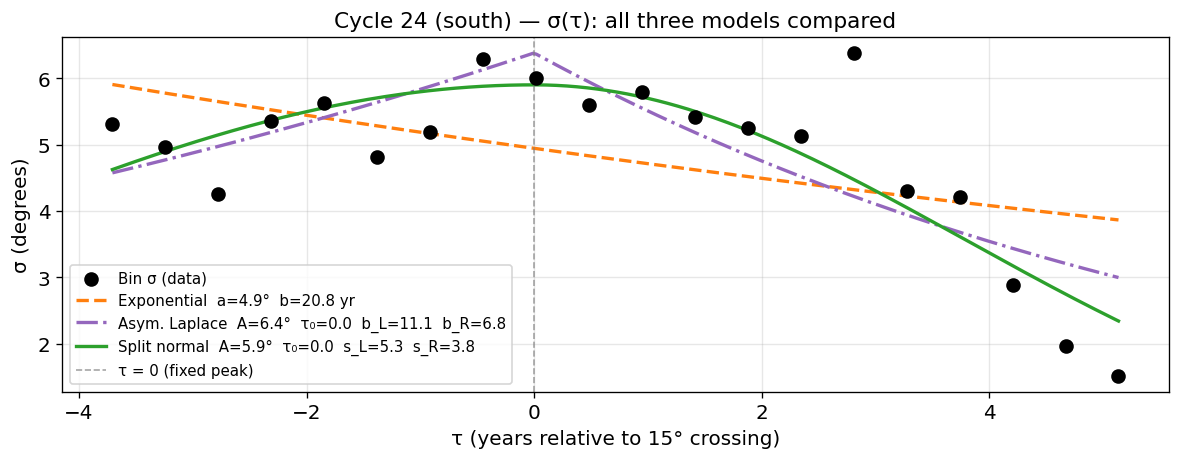

RMSE — exponential:        1.105°
RMSE — asymmetric Laplace: 0.787°
RMSE — split normal:       0.641°
Key difference vs. asymmetric Laplace:
  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges
  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly
  If the post-crossing decay is truly nearly linear, Laplace fits better;
  if it curves inward toward zero, split normal fits better.


In [16]:
# Task 11 2nd expansion: Split normal fit for σ(τ) — compare all three models
# Requires Task 11 expansion to have been run (uses bin_tau, bin_sigma, a_sigma, b_sigma,
# A_al, tau0_al, bL_al, bR_al, cycle_sel, hemi_sel)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian).

    Two half-Gaussians joined at the peak.  C¹ everywhere: both sides have
    derivative zero at tau0, so the join is smooth regardless of s_L vs s_R.
    Not C²: the curvatures -A/s_L² and -A/s_R² differ when s_L ≠ s_R.

    Parameters
    ----------
    A          : peak σ value (degrees)
    tau0       : peak location — used only when tau0_fixed is None
    s_L        : left Gaussian width  — larger → gentler rise  (years)
    s_R        : right Gaussian width — smaller → steeper fall (years)
    tau0_fixed : if not None, overrides tau0 and is not fitted (default None)
    """
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

# Fix tau0 = 0
TAU0_FIXED = 0.0
_sn_fixed = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

p0_sn = [bin_sigma.max(), 4.0, 2.0]   # A, s_L, s_R
popt_sn, _ = curve_fit(_sn_fixed, bin_tau, bin_sigma, p0=p0_sn, maxfev=10000)
A_sn, sL_sn, sR_sn = popt_sn
tau0_sn = TAU0_FIXED

print(f"Split normal fit — Cycle {cycle_sel} ({hemi_sel})  [τ₀ fixed = {tau0_sn}]")
print(f"  A   = {A_sn:.2f}°   (peak spread)")
print(f"  s_L = {sL_sn:.2f} yr  (left Gaussian width  — rising phase)")
print(f"  s_R = {sR_sn:.2f} yr  (right Gaussian width — decaying phase)")
print(f"  s_L / s_R = {sL_sn/sR_sn:.2f}  — rise is ~{sL_sn/sR_sn:.1f}× broader than the fall")

# --- Three-way comparison plot ---
tau_grid_sn = np.linspace(bin_tau.min(), bin_tau.max(), 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(bin_tau, bin_sigma, color="black", s=60, zorder=5, label="Bin σ (data)")

ax.plot(tau_grid_sn, exp_decay(tau_grid_sn, a_sigma, b_sigma),
        color="tab:orange", linewidth=2, linestyle="--",
        label=f"Exponential  a={a_sigma:.1f}°  b={b_sigma:.1f} yr")

ax.plot(tau_grid_sn, asym_laplace(tau_grid_sn, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al),
        color="tab:purple", linewidth=2, linestyle="-.",
        label=f"Asym. Laplace  A={A_al:.1f}°  τ₀={tau0_al}  b_L={bL_al:.1f}  b_R={bR_al:.1f}")

ax.plot(tau_grid_sn, split_normal(tau_grid_sn, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn),
        color="tab:green", linewidth=2,
        label=f"Split normal  A={A_sn:.1f}°  τ₀={tau0_sn}  s_L={sL_sn:.1f}  s_R={sR_sn:.1f}")

ax.axvline(0, color="gray", linewidth=1, linestyle="--", alpha=0.7, label="τ = 0 (fixed peak)")
ax.set_xlabel("τ (years relative to 15° crossing)")
ax.set_ylabel("σ (degrees)")
ax.set_title(f"Cycle {cycle_sel} ({hemi_sel}) — σ(τ): all three models compared")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- RMSE comparison (all three) ---
resid_exp = bin_sigma - exp_decay(bin_tau, a_sigma, b_sigma)
resid_al  = bin_sigma - asym_laplace(bin_tau, A_al, None, bL_al, bR_al, tau0_fixed=tau0_al)
resid_sn  = bin_sigma - split_normal(bin_tau, A_sn, None, sL_sn, sR_sn, tau0_fixed=tau0_sn)

print(f"RMSE — exponential:        {np.sqrt(np.mean(resid_exp**2)):.3f}°")
print(f"RMSE — asymmetric Laplace: {np.sqrt(np.mean(resid_al**2)):.3f}°")
print(f"RMSE — split normal:       {np.sqrt(np.mean(resid_sn**2)):.3f}°")
print("Key difference vs. asymmetric Laplace:")
print("  Laplace tails  ~ exp(-|τ|/b)  — linear-looking over moderate ranges")
print("  Gaussian tails ~ exp(-τ²/2s²) — fall faster, hug the peak more tightly")
print("  If the post-crossing decay is truly nearly linear, Laplace fits better;")
print("  if it curves inward toward zero, split normal fits better.")


## 12) Exercise: Ensemble Variability and the Mean Butterfly Template

One hemisphere-cycle's μ(τ) fit is one realization. The *spread* across many realizations is the scientific signal — it encodes cycle-to-cycle and hemisphere-to-hemisphere variability, and it defines what a generative model eventually needs to reproduce.

**Task:**
- Repeat the Task 10 and Task 11 pipelines for **all** hemisphere-cycles with sufficient data (e.g. cycles 12–24, both hemispheres → up to ~26 fits). For each, store the best-fit (a, b) pair for μ(τ) and σ(τ).
- Evaluate every fitted exponential on a common τ grid: `tau_grid = np.linspace(-6, 6, 300)`. Collect results into two arrays of shape `(n_hemicycles, 300)` for μ and σ.
- On a single figure with **two panels** (top: μ(τ), bottom: σ(τ)), plot each hemisphere-cycle as a thin colored line. Overlay the **pointwise mean** and **±1σ envelope** in black.
  - *Hint:* Use `np.nanmean` and `np.nanstd` along axis 0 to handle hemisphere-cycles that don't cover the full τ grid.
- As a separate figure, make a **scatter plot of the fitted (a, b) parameters** across all hemisphere-cycles, colored by cycle number. This is the parameter space of your model.

Successfully fitted 22 hemisphere-cycles.


/tmp/ipykernel_1282/2613346926.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))


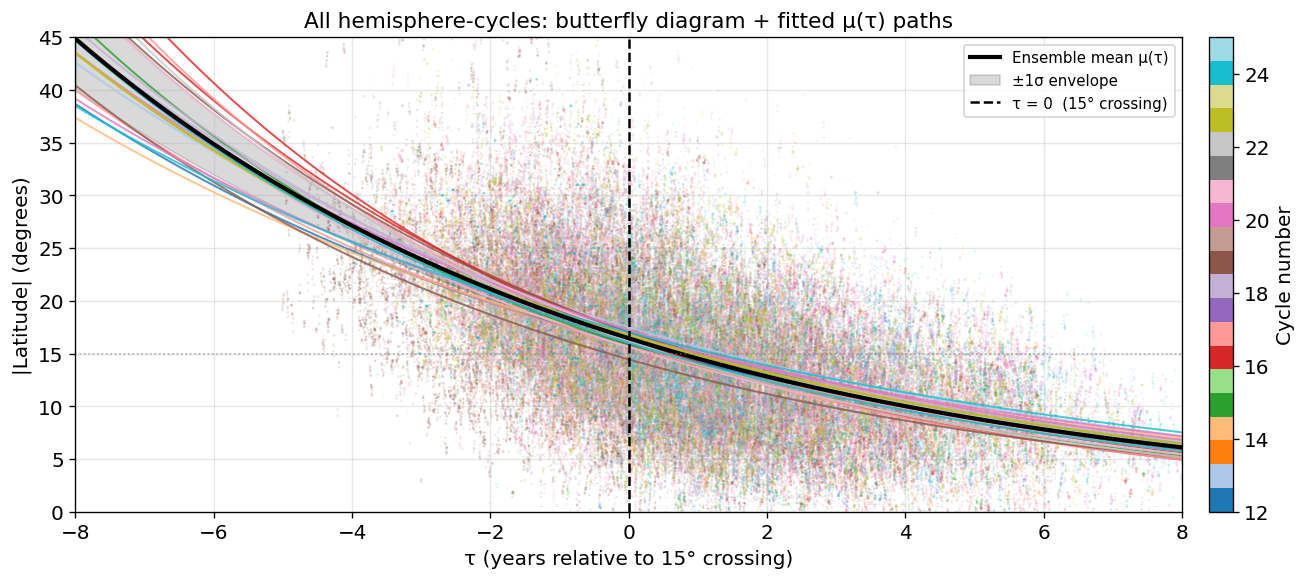

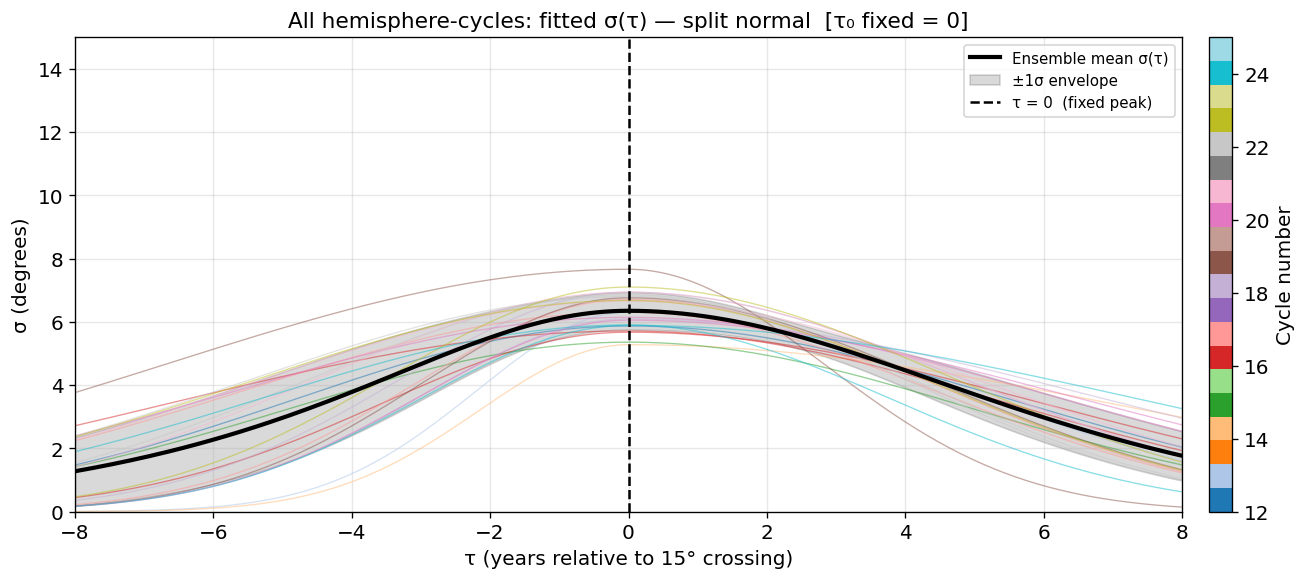

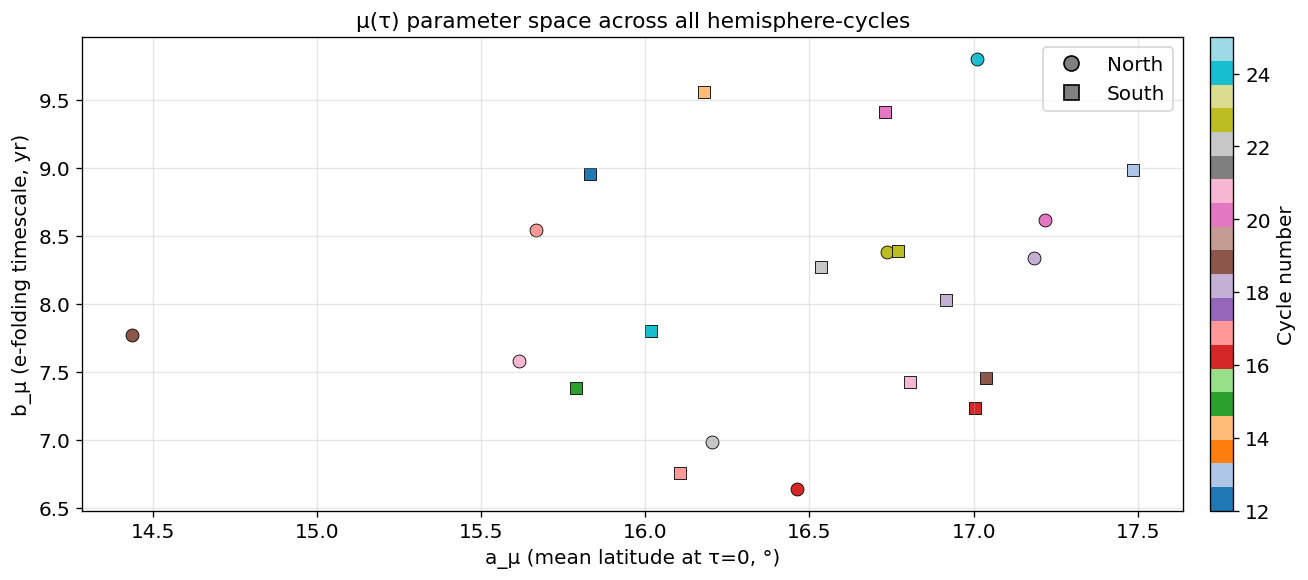

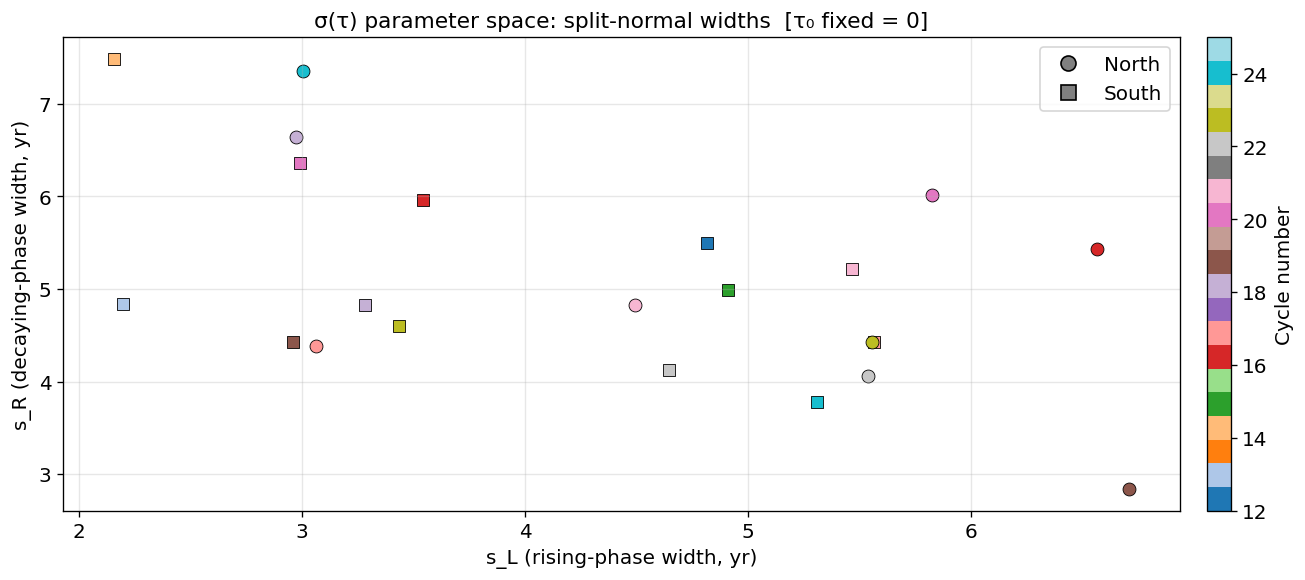

Parameter summary across 22 hemisphere-cycles  [σ τ₀ fixed = 0.0]:
  a_μ :  16.44° ± 0.69°
  b_μ :  8.10 yr ± 0.87 yr
  A_σ :  6.35° ± 0.59°
  s_L :  4.32 yr ± 1.36 yr
  s_R :  5.11 yr ± 1.13 yr


In [17]:
# Task 12: Ensemble variability and the mean butterfly template
# Uses exponential decay for μ(τ) and split normal for σ(τ) with τ₀ fixed at 0
# Requires Task 9 (t0_lookup, df["tau"], df["abs_latitude"])
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

def split_normal(tau, A, tau0, s_L, s_R, tau0_fixed=None):
    t0 = tau0_fixed if tau0_fixed is not None else tau0
    return np.where(tau < t0,
                    A * np.exp(-0.5 * ((tau - t0) / s_L) ** 2),
                    A * np.exp(-0.5 * ((tau - t0) / s_R) ** 2))

TAU0_FIXED   = 0.0
_sn_fixed    = lambda tau, A, s_L, s_R: split_normal(tau, A, None, s_L, s_R, tau0_fixed=TAU0_FIXED)

N_BINS   = 20
TAU_GRID = np.linspace(-8, 8, 300)

cycles_to_fit = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
hemispheres   = ["north", "south"]

results = []

for cyc in cycles_to_fit:
    for hemi in hemispheres:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue

        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins         = np.linspace(t_min, t_max, N_BINS + 1)
        bin_centers  = 0.5 * (bins[:-1] + bins[1:])

        bt, bm, bs = [], [], []
        for i in range(N_BINS):
            in_bin   = (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1])
            lats_bin = df_sel.loc[in_bin, "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f); bs.append(sigma_f)

        if len(bt) < 5:
            continue

        bt, bm, bs = np.array(bt), np.array(bm), np.array(bs)

        try:
            popt_mu,    _ = curve_fit(exp_decay, bt, bm, p0=[15., 5.], maxfev=5000)
            popt_sigma, _ = curve_fit(_sn_fixed, bt, bs, p0=[bs.max(), 4., 2.], maxfev=5000)
        except RuntimeError:
            continue

        a_mu_f, b_mu_f     = popt_mu
        A_sn_f, sL_sn_f, sR_sn_f = popt_sigma

        if not (5 < a_mu_f < 40 and 1 < b_mu_f < 30):
            continue
        if not (1 < A_sn_f < 20 and 0.5 < sL_sn_f < 20 and 0.5 < sR_sn_f < 20):
            continue

        results.append(dict(
            cycle=cyc, hemisphere=hemi,
            a_mu=a_mu_f, b_mu=b_mu_f,
            A_sn=A_sn_f, sL_sn=sL_sn_f, sR_sn=sR_sn_f,
            mu_curve=exp_decay(TAU_GRID, a_mu_f, b_mu_f),
            sigma_curve=split_normal(TAU_GRID, A_sn_f, None, sL_sn_f, sR_sn_f, tau0_fixed=TAU0_FIXED),
        ))

print(f"Successfully fitted {len(results)} hemisphere-cycles.")

# --- Ensemble statistics ---
mu_mat    = np.array([r["mu_curve"]    for r in results])
sigma_mat = np.array([r["sigma_curve"] for r in results])

mu_mean    = np.nanmean(mu_mat,    axis=0);  mu_std    = np.nanstd(mu_mat,    axis=0)
sigma_mean = np.nanmean(sigma_mat, axis=0);  sigma_std = np.nanstd(sigma_mat, axis=0)

cmap_ens      = cm.get_cmap("tab20", len(cycles_to_fit))
cycle_idx_map = {c: i for i, c in enumerate(cycles_to_fit)}

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=9,
           label="North", markeredgecolor="black"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markersize=9,
           label="South", markeredgecolor="black"),
]

def add_cycle_colorbar(fig, ax):
    sm = plt.cm.ScalarMappable(cmap="tab20",
                               norm=plt.Normalize(vmin=min(cycles_to_fit),
                                                  vmax=max(cycles_to_fit)))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

# ── Figure 1: μ(τ) fitted curves overlaid on the aligned butterfly diagram ──
fig1, ax1 = plt.subplots(figsize=(12, 5))

for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in t0_lookup or cyc not in cycle_idx_map:
        continue
    ax1.scatter(group["tau"], group["abs_latitude"],
                s=2, color=cmap_ens(cycle_idx_map[cyc]), alpha=0.15, edgecolors="none")

for r in results:
    ax1.plot(TAU_GRID, r["mu_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=1.2, alpha=0.8)

ax1.plot(TAU_GRID, mu_mean, color="black", linewidth=2.5, label="Ensemble mean μ(τ)")
ax1.fill_between(TAU_GRID, mu_mean - mu_std, mu_mean + mu_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax1.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (15° crossing)")
ax1.axhline(15, color="gray", linewidth=1, linestyle=":", alpha=0.6)
ax1.set_xlabel("τ (years relative to 15° crossing)")
ax1.set_ylabel("|Latitude| (degrees)")
ax1.set_title("All hemisphere-cycles: butterfly diagram + fitted μ(τ) paths")
ax1.set_ylim(0, 45)
ax1.set_xlim(-8, 8)
ax1.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig1, ax1)
plt.tight_layout()
plt.show()

# ── Figure 2: σ(τ) split normal fits ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for r in results:
    ax2.plot(TAU_GRID, r["sigma_curve"],
             color=cmap_ens(cycle_idx_map[r["cycle"]]), linewidth=0.8, alpha=0.5)

ax2.plot(TAU_GRID, sigma_mean, color="black", linewidth=2.5, label="Ensemble mean σ(τ)")
ax2.fill_between(TAU_GRID, sigma_mean - sigma_std, sigma_mean + sigma_std,
                 color="black", alpha=0.15, label="±1σ envelope")
ax2.axvline(0, color="black", linewidth=1.5, linestyle="--", label="τ = 0  (fixed peak)")
ax2.set_xlabel("τ (years relative to 15° crossing)")
ax2.set_ylabel("σ (degrees)")
ax2.set_title("All hemisphere-cycles: fitted σ(τ) — split normal  [τ₀ fixed = 0]")
ax2.set_ylim(0, 15)
ax2.set_xlim(-8, 8)
ax2.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig2, ax2)
plt.tight_layout()
plt.show()

# ── Figure 3: μ parameter scatter (a_mu vs b_mu) ───────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 5))

for r in results:
    ax3.scatter(r["a_mu"], r["b_mu"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax3.set_xlabel("a_μ (mean latitude at τ=0, °)")
ax3.set_ylabel("b_μ (e-folding timescale, yr)")
ax3.set_title("μ(τ) parameter space across all hemisphere-cycles")
ax3.legend(handles=legend_handles)
add_cycle_colorbar(fig3, ax3)
plt.tight_layout()
plt.show()

# ── Figure 4: σ parameter scatter (s_L vs s_R) ─────────────────────────────
fig4, ax4 = plt.subplots(figsize=(12, 5))

for r in results:
    ax4.scatter(r["sL_sn"], r["sR_sn"],
                color=cmap_ens(cycle_idx_map[r["cycle"]]),
                marker="o" if r["hemisphere"] == "north" else "s",
                s=60, edgecolors="black", linewidths=0.5)

ax4.set_xlabel("s_L (rising-phase width, yr)")
ax4.set_ylabel("s_R (decaying-phase width, yr)")
ax4.set_title("σ(τ) parameter space: split-normal widths  [τ₀ fixed = 0]")
ax4.legend(handles=legend_handles)
add_cycle_colorbar(fig4, ax4)
plt.tight_layout()
plt.show()

# ── Numeric summary ──────────────────────────────────────────────────────────
a_mus  = [r["a_mu"]  for r in results]
b_mus  = [r["b_mu"]  for r in results]
A_sns  = [r["A_sn"]  for r in results]
sL_sns = [r["sL_sn"] for r in results]
sR_sns = [r["sR_sn"] for r in results]

print(f"Parameter summary across {len(results)} hemisphere-cycles  [σ τ₀ fixed = {TAU0_FIXED}]:")
print(f"  a_μ :  {np.mean(a_mus):.2f}° ± {np.std(a_mus):.2f}°")
print(f"  b_μ :  {np.mean(b_mus):.2f} yr ± {np.std(b_mus):.2f} yr")
print(f"  A_σ :  {np.mean(A_sns):.2f}° ± {np.std(A_sns):.2f}°")
print(f"  s_L :  {np.mean(sL_sns):.2f} yr ± {np.std(sL_sns):.2f} yr")
print(f"  s_R :  {np.mean(sR_sns):.2f} yr ± {np.std(sR_sns):.2f} yr")


---
## Week 04 Exercises: Toward a Universal Description of the Solar Cycle

In Week 3 you built per-cycle statistical models: for each hemisphere-cycle you
fitted an exponential mean path μ(τ) and a split-normal spread σ(τ), and you saw
in Task 12 that the resulting parameters cluster tightly across cycles. That
clustering is the starting point for this week.

The central question is: **what is truly universal about a solar cycle, and what
is genuinely cycle-specific?**

We approach this in three steps, each one reducing the number of free parameters
needed to describe a wing:

**Task 13 — Universal mean path.**
All cycles share the same exponential decay shape μ(τ) = a_μ exp(−τ/b_μ).
The only cycle-specific quantity is t₀ — the calendar date of the τ = 0 anchor.
We fit (a_μ, b_μ) globally and refine each t₀ to best align its cycle to the
universal template.

**Tasks 14 & 15 — Remapping σ from time to latitude.**
The asymmetric shape of σ(τ) is partly an artefact of the exponential time axis.
Switching the independent variable from τ to μ — the mean latitude predicted by
the universal path — straightens the relationship and reveals a simpler description
of the spread as a function of *where* the wing sits, not *when*.

**Task 16 — Shared shape parameters.**
Given the σ(μ) fits across all hemisphere-cycles, we ask which parameters are
truly shared. Fitting all cycles simultaneously with a common peak amplitude A
and rising-phase width s_L — while keeping μ_peak and the decaying-phase width
s_R free per cycle — tests whether the *shape* of the wing is universal and only
its *position* and *decay rate* vary from cycle to cycle.

Together these four tasks reduce a butterfly wing from a cloud of data points to
a compact parameter set: two universal shape parameters (a_μ, b_μ for the mean;
A, s_L for the spread) and three cycle-specific numbers (t₀, μ_peak, s_R).
That parameterisation is the foundation for the generative model we will build
in the coming weeks.


---
## 13) Exercise: Fitting a Universal Mean Path

In Week 3 you fitted separate (a_μ, b_μ) per hemisphere-cycle. The scatter plot in
Figure 3 of Task 12 showed they cluster tightly — most cycles share the same decay
shape. The scatter is noise, not signal. The physically motivated model is:

$$\mu(t,\,\text{cycle}) = a_\mu \cdot \exp\!\left(-\frac{\text{decimal\_year}(t) - t_{0,\text{cycle}}}{b_\mu}\right)$$

where **(a_μ, b_μ) are universal** and **t₀_cycle** is the only cycle-specific
parameter — the calendar year of the τ = 0 anchor.
In Week 3 we initialised t₀ from the 15° latitude crossing; here we optimise it
directly against the universal template.

**Steps:**

1. **Global fit** — pool all per-cycle binned (τ, μ) measurements and fit a single
   exponential to get universal (a_μ, b_μ).
2. **Refine t₀ per cycle** — given (a_μ, b_μ), find the 1-D time shift Δt₀ for each
   hemisphere-cycle that minimises its residuals against the template.
   Repeat for a few iterations until convergence.
3. **Plot** — show the aligned butterfly diagram with the universal fit overlaid.
   All wings should collapse onto a single curve.
4. **Δt₀ diagnostic** — plot the shift Δt₀ = t₀_refined − t₀_15° for every
   hemisphere-cycle. Which cycles needed large corrections? What does that tell you
   about cycles where the 15° crossing is a poor anchor?


Universal mean path fit: a_μ = 16.44°, b_μ = 8.15 yr


/tmp/ipykernel_1282/3107283671.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_cyc = cm.get_cmap("tab20", len(cycles_to_plot))


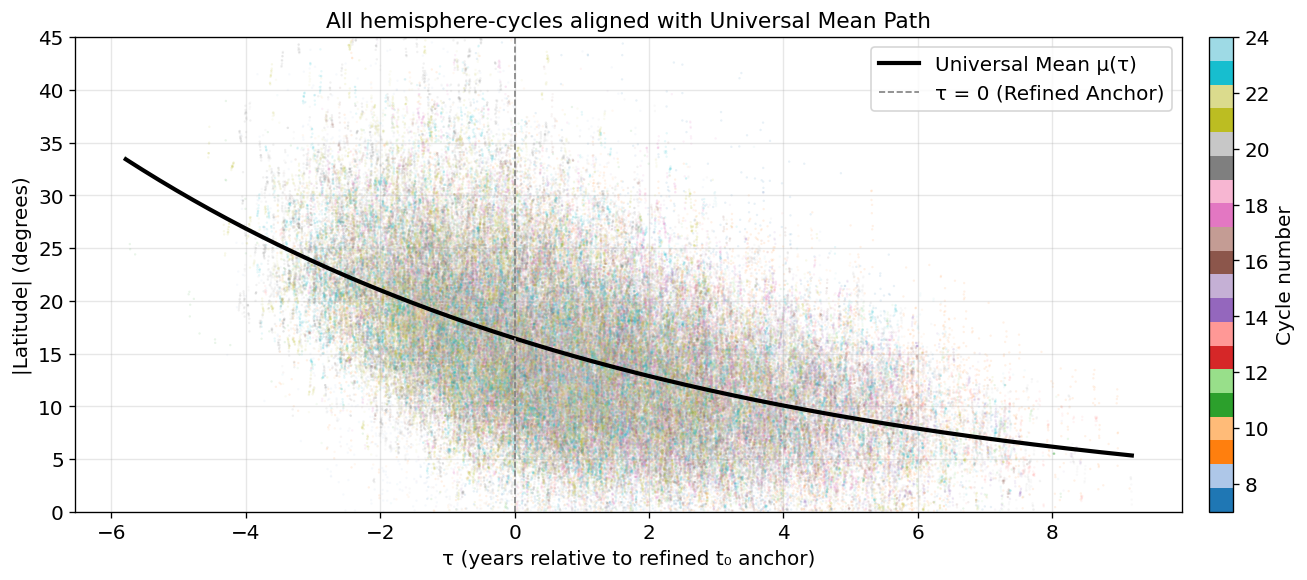


Δt₀ (refined t₀ - initial 15° crossing t₀) for each hemisphere-cycle:
  Cycle 7 (north): Δt₀ = -0.00 yr (Initial t0: 1826.68)
  Cycle 7 (south): Δt₀ = -0.03 yr (Initial t0: 1827.91)
  Cycle 8 (north): Δt₀ = -0.04 yr (Initial t0: 1838.56)
  Cycle 8 (south): Δt₀ = -1.19 yr (Initial t0: 1839.05)
  Cycle 9 (north): Δt₀ = -0.38 yr (Initial t0: 1848.26)
  Cycle 9 (south): Δt₀ = -0.50 yr (Initial t0: 1848.17)
  Cycle 10 (north): Δt₀ = -0.44 yr (Initial t0: 1860.65)
  Cycle 10 (south): Δt₀ = -0.43 yr (Initial t0: 1860.49)
  Cycle 11 (north): Δt₀ = -0.55 yr (Initial t0: 1872.06)
  Cycle 11 (south): Δt₀ = -0.06 yr (Initial t0: 1870.90)
  Cycle 12 (north): Δt₀ = -0.18 yr (Initial t0: 1881.96)
  Cycle 12 (south): Δt₀ = -0.29 yr (Initial t0: 1882.61)
  Cycle 13 (north): Δt₀ = -0.06 yr (Initial t0: 1892.80)
  Cycle 13 (south): Δt₀ = 0.40 yr (Initial t0: 1893.05)
  Cycle 14 (north): Δt₀ = -0.09 yr (Initial t0: 1904.34)
  Cycle 14 (south): Δt₀ = 0.04 yr (Initial t0: 1905.39)
  Cycle 15 (north): Δt₀ =

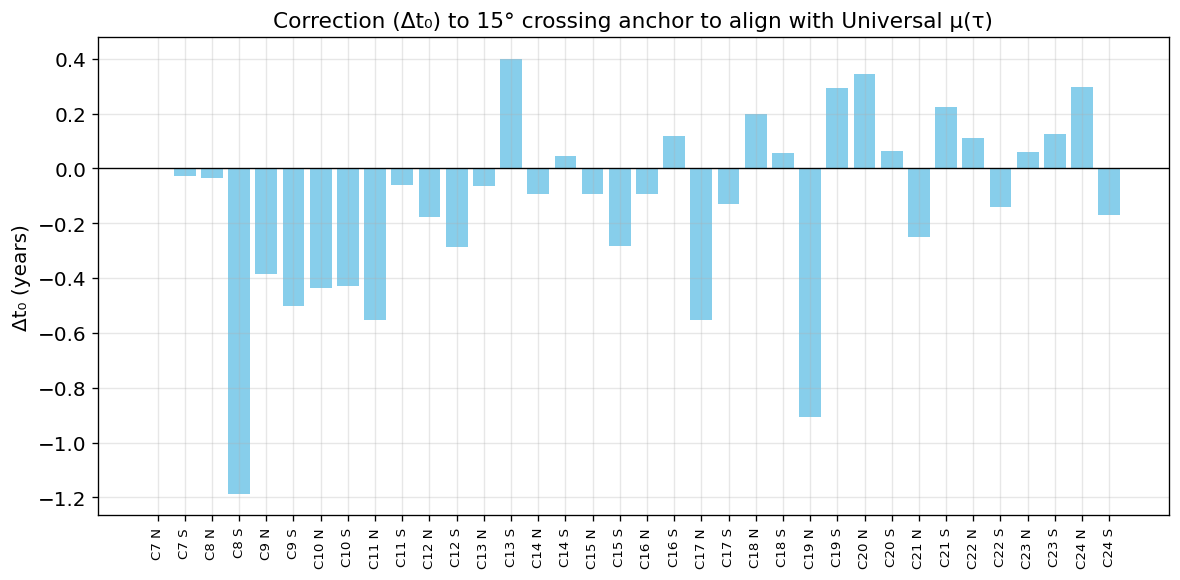

In [22]:
# Task 13: Fitting a Universal Mean Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from scipy.stats import norm as sp_norm

# Re-define exp_decay for clarity, although it's likely already in kernel scope
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

# Step 1: Global fit for (a_mu, b_mu)
all_binned_tau = []
all_binned_mu = []

# Collect binned data from all successful fits in Task 12 results
# (assuming 'results' from Task 12 is available in kernel from prior execution)
for r in results:
    cyc = r["cycle"]
    hemi = r["hemisphere"]
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
    df_sel_cyc = df[mask].copy()

    t_min, t_max = df_sel_cyc["tau"].min(), df_sel_cyc["tau"].max()
    # Ensure bins are created even if t_min == t_max for very small datasets
    # or if the min/max is from a single point which might happen if data is sparse.
    # Adjusting N_BINS to ensure enough distinct bins.
    current_n_bins = min(N_BINS, max(1, len(df_sel_cyc) // 10)) # Ensure at least 1 bin if data exists
    if current_n_bins < 1:
        continue

    bins = np.linspace(t_min, t_max, current_n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    bin_tau_cyc, bin_mu_cyc = [], []
    for i in range(current_n_bins):
        # Use > and <= for binning to avoid floating point issues and ensure all points go into one bin.
        if i == current_n_bins - 1: # Last bin includes the max value
            in_bin = (df_sel_cyc["tau"] >= bins[i]) & (df_sel_cyc["tau"] <= bins[i + 1])
        else:
            in_bin = (df_sel_cyc["tau"] >= bins[i]) & (df_sel_cyc["tau"] < bins[i + 1])
        lats_bin = df_sel_cyc.loc[in_bin, "abs_latitude"].values
        if len(lats_bin) < 10: # Minimum data points for a meaningful fit
            continue
        mu_f, _ = sp_norm.fit(lats_bin)
        bin_tau_cyc.append(bin_centers[i])
        bin_mu_cyc.append(mu_f)

    all_binned_tau.extend(bin_tau_cyc)
    all_binned_mu.extend(bin_mu_cyc)

all_binned_tau = np.array(all_binned_tau)
all_binned_mu = np.array(all_binned_mu)

# Filter out NaN or inf values that might arise from empty bins or bad data
valid_indices = np.isfinite(all_binned_tau) & np.isfinite(all_binned_mu)
all_binned_tau = all_binned_tau[valid_indices]
all_binned_mu = all_binned_mu[valid_indices]

if len(all_binned_tau) == 0:
    print("Not enough data to perform global fit for universal mean path.")
else:
    try:
        popt_universal_mu, _ = curve_fit(exp_decay, all_binned_tau, all_binned_mu, p0=[15.0, 7.0])
        universal_a_mu, universal_b_mu = popt_universal_mu
        print(f"Universal mean path fit: a_μ = {universal_a_mu:.2f}°, b_μ = {universal_b_mu:.2f} yr")

        # Step 2: Refine t0 per cycle
        refined_t0_lookup = {}
        delta_t0_corrections = {} # Store delta_t0 = t0_refined - t0_initial_15deg

        for (cyc, hemi) in t0_lookup: # Iterate over all (cycle, hemi) pairs that had an initial t0
            mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
            df_cyc_hemi = df[mask].copy()

            if len(df_cyc_hemi) < 50: # Skip if not enough data for individual refinement
                continue

            initial_t0_15deg = t0_lookup[(cyc, hemi)]

            # Define a new function to fit t0_offset for the current cycle, given universal a_mu, b_mu
            def mu_template_with_t0_offset(decimal_year, t0_offset):
                current_t0 = initial_t0_15deg + t0_offset
                tau_val = decimal_year - current_t0
                # Ensure tau_val is not too extreme for exp_decay to avoid overflow
                tau_val = np.clip(tau_val, -100, 100) # Clip to a reasonable range
                return exp_decay(tau_val, universal_a_mu, universal_b_mu)

            # Use df_cyc_hemi's actual decimal_year and abs_latitude to find the best t0_offset
            try:
                popt_t0_offset, _ = curve_fit(mu_template_with_t0_offset,
                                              df_cyc_hemi["decimal_year"].values,
                                              df_cyc_hemi["abs_latitude"].values,
                                              p0=[0.0]) # Initial guess for offset is 0
                t0_offset = popt_t0_offset[0]
                refined_t0 = initial_t0_15deg + t0_offset
                refined_t0_lookup[(cyc, hemi)] = refined_t0
                delta_t0_corrections[(cyc, hemi)] = t0_offset
            except RuntimeError:
                print(f"  Could not refine t0 for Cycle {int(cyc)} ({hemi})")
                continue

        # Update the 'tau' column in the main DataFrame with refined t0 values
        # It's better to create new columns to not overwrite existing 'tau' and 't0'
        # and to handle cases where some cycles might not have been refined.
        df["t0_refined"] = df.apply(lambda row: refined_t0_lookup.get((row["CYCLE"], row["hemisphere"]), np.nan), axis=1)
        df["tau_refined"] = df["decimal_year"] - df["t0_refined"]

        # Step 3: Plot the aligned butterfly diagram with the universal fit overlaid
        fig, ax = plt.subplots(figsize=(12, 5))

        cycles_to_plot = sorted({cyc for (cyc, hemi) in refined_t0_lookup})
        cmap_cyc = cm.get_cmap("tab20", len(cycles_to_plot))
        cycle_color_map = {cyc: cmap_cyc(i) for i, cyc in enumerate(cycles_to_plot)}

        # Plot individual sunspot groups with refined tau
        for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
            if (cyc, hemi) not in refined_t0_lookup: # Only plot cycles that were successfully refined
                continue
            # Filter out NaNs in 'tau_refined' if any cycle couldn't be refined
            plot_data = group.dropna(subset=["tau_refined", "abs_latitude"])
            ax.scatter(plot_data["tau_refined"], plot_data["abs_latitude"],
                       s=2, color=cycle_color_map[cyc], alpha=0.1, edgecolors="none")

        # Plot the universal mean path
        # Use a tau range that covers the observed refined tau values
        min_tau_refined = df["tau_refined"].min()
        max_tau_refined = df["tau_refined"].max()
        tau_plot_grid = np.linspace(min_tau_refined if np.isfinite(min_tau_refined) else -8,
                                    max_tau_refined if np.isfinite(max_tau_refined) else 8, 300)

        universal_mu_curve = exp_decay(tau_plot_grid, universal_a_mu, universal_b_mu)
        ax.plot(tau_plot_grid, universal_mu_curve, color="black", linewidth=2.5, linestyle="-", label="Universal Mean μ(τ)")

        ax.axvline(0, color="gray", linewidth=1, linestyle="--", label="τ = 0 (Refined Anchor)")
        ax.set_xlabel("τ (years relative to refined t₀ anchor)")
        ax.set_ylabel("|Latitude| (degrees)")
        ax.set_title("All hemisphere-cycles aligned with Universal Mean Path")
        ax.set_ylim(0, 45)
        ax.legend()

        sm = plt.cm.ScalarMappable(cmap="tab20",
                                    norm=plt.Normalize(vmin=min(cycles_to_plot),
                                                       vmax=max(cycles_to_plot)))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")
        plt.tight_layout()
        plt.show()

        # Step 4: Δt0 diagnostic
        print("\nΔt₀ (refined t₀ - initial 15° crossing t₀) for each hemisphere-cycle:")
        delta_t0_values = []
        for (cyc, hemi), dt0 in delta_t0_corrections.items():
            initial_t0 = t0_lookup.get((cyc, hemi))
            if initial_t0 is not None:
                print(f"  Cycle {int(cyc)} ({hemi}): Δt₀ = {dt0:.2f} yr (Initial t0: {initial_t0:.2f})")
                delta_t0_values.append(dt0)

        if delta_t0_values:
            print(f"\nMean absolute Δt₀: {np.mean(np.abs(delta_t0_values)):.2f} yr")

            fig_dt0, ax_dt0 = plt.subplots(figsize=(10, 5))
            cycles_and_hemis = list(delta_t0_corrections.keys())
            dt0s = list(delta_t0_corrections.values())

            bars = ax_dt0.bar(range(len(cycles_and_hemis)), dt0s, color='skyblue')
            ax_dt0.axhline(0, color='black', linewidth=0.8)
            ax_dt0.set_xticks(range(len(cycles_and_hemis)))
            ax_dt0.set_xticklabels([f"C{int(c[0])} {c[1][0].upper()}" for c in cycles_and_hemis], rotation=90, fontsize=8)
            ax_dt0.set_ylabel("Δt₀ (years)")
            ax_dt0.set_title("Correction (Δt₀) to 15° crossing anchor to align with Universal μ(τ)")
            plt.tight_layout()
            plt.show()
        else:
            print("No delta t0 values to plot.")

    except Exception as e:
        print(f"An error occurred during universal mean path fitting or refinement: {e}")

## 14) Exercise: Fitting σ as a Function of Mean Latitude

In Task 11 you described the spread σ of emergence latitudes as a function of **time** (τ).
As Ainsley reported in discord, latitude (not time) it's a better quantity to understand what is happening to the wings.
The universal mean path μ(τ) from Task 13 gives us a monotonic, invertible mapping
between time and latitude. We can therefore reparametrise and ask:
**what is σ as a function of μ?**

**Task:**

- Pick a single hemisphere-cycle (e.g. cycle 23, northern hemisphere).
  Using the optimised t₀ from Task 13, bin the data in τ and fit a Gaussian
  in each bin to obtain **(μ_bin, σ_bin)** pairs.
- Plot σ_bin as a function of μ_bin. Describe the shape you see.
- Start by fitting a **split normal** to σ(μ). Does it capture the shape well?
- Ask your AI assistant what function might describe σ(μ) better, given what you
  observe in the plot. Try its suggestion and compare.

**Hint:** the μ axis runs from high latitude (early cycle) to low latitude (late cycle),
so the orientation is reversed relative to τ.   Reverse the x axis so that things look "right".


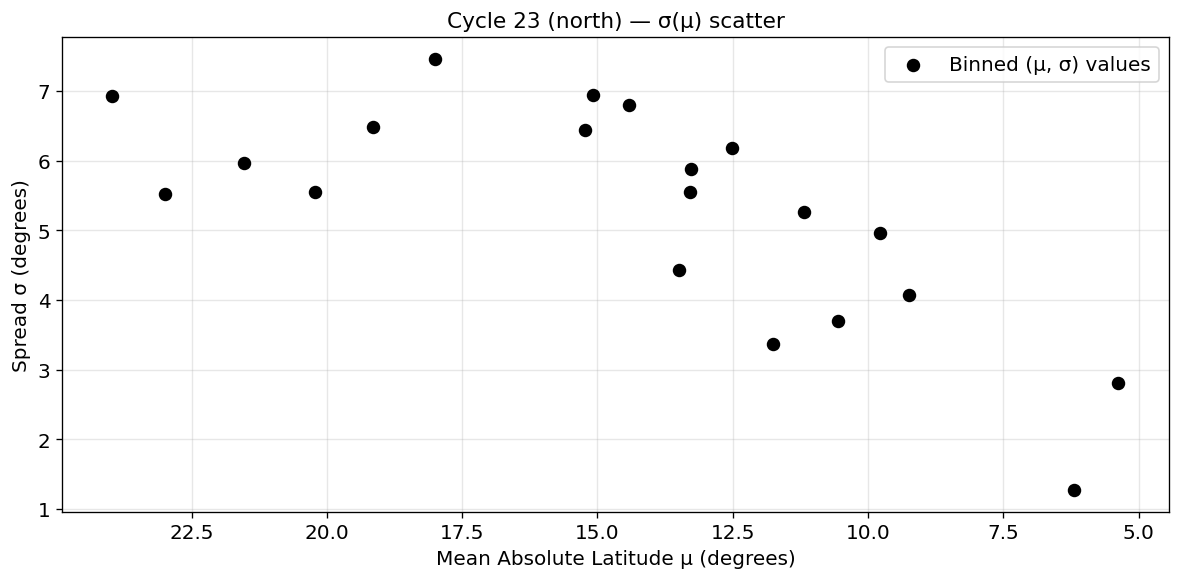

The plot shows that the spread (σ) is relatively small at high latitudes (early cycle), increases to a peak, and then decreases again as the mean latitude approaches the equator.
This shape suggests an asymmetric curve, possibly a split normal (Gaussian) or asymmetric Laplace distribution.

Split normal fit for σ(μ) — Cycle 23 (north):
  A           = 6.55°   (peak spread)
  μ_peak      = 17.36°  (mean latitude where spread peaks)
  s_higher_mu = 17.16°  (Gaussian width for μ > μ_peak)
  s_lower_mu  = 7.68°  (Gaussian width for μ < μ_peak)
  s_higher_mu / s_lower_mu = 2.23  — the spread profile is ~2.2× broader for high μ than low μ


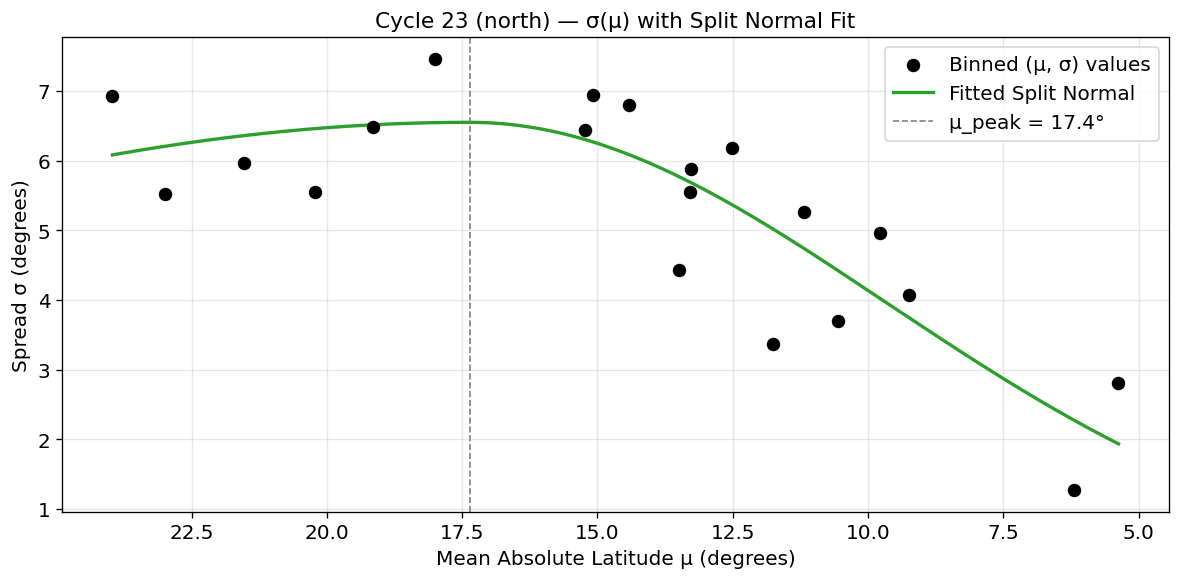

In [23]:
# Task 14: Fitting sigma as a function of mean latitude
# Requires Task 13 to have been run (uses df["tau_refined"], df["abs_latitude"], refined_t0_lookup)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit

# Definition of split_normal, adapted for mu as the independent variable.
# Renaming parameters for clarity in the context of mu.
def split_normal_mu(mu_val, A, mu_peak_loc, s_higher_mu, s_lower_mu, mu_peak_loc_fixed=None):
    """
    Split normal (bi-normal / asymmetric Gaussian) adapted for mean absolute latitude (mu) as the x-axis.

    Parameters
    ----------
    mu_val            : The mean absolute latitude value (independent variable).
    A                 : Peak sigma value (amplitude).
    mu_peak_loc       : Mean latitude where the spread (sigma) peaks.
    s_higher_mu       : Gaussian width parameter for mu_val > mu_peak_loc (corresponding to earlier cycle, higher latitudes).
    s_lower_mu        : Gaussian width parameter for mu_val < mu_peak_loc (corresponding to later cycle, lower latitudes).
    mu_peak_loc_fixed : If not None, overrides mu_peak_loc and is not fitted (default None).
    """
    peak_lat = mu_peak_loc_fixed if mu_peak_loc_fixed is not None else mu_peak_loc
    return np.where(mu_val > peak_lat, # This part corresponds to higher latitudes (earlier in cycle)
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_higher_mu) ** 2),
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_lower_mu) ** 2))

choose_cycle = 23
choose_hemi = 'north'

# Filter data for the chosen cycle and hemisphere using refined tau
mask = (df["CYCLE"] == choose_cycle) & \
       (df["hemisphere"] == choose_hemi) & \
       df["tau_refined"].notna() # Use tau_refined from Task 13
df_sel_14 = df[mask].copy()

if len(df_sel_14) == 0:
    print(f"No data for Cycle {choose_cycle} ({choose_hemi}) with refined tau. Skipping Task 14.")
else:
    # Bin the tau_refined axis and fit a Gaussian in each bin
    N_bins = 20
    tau_refined_min = df_sel_14["tau_refined"].min() if not df_sel_14["tau_refined"].empty else -5
    tau_refined_max = df_sel_14["tau_refined"].max() if not df_sel_14["tau_refined"].empty else 5

    # Handle cases where min == max or not enough range
    if tau_refined_max - tau_refined_min < 0.1: # Small range, create a minimal set of bins
        bins = np.array([tau_refined_min, (tau_refined_min + tau_refined_max) / 2, tau_refined_max + 0.1])
        bin_tau_centers = 0.5 * (bins[:-1] + bins[1:])
        current_N_bins = len(bin_tau_centers)
    else:
        bins = np.linspace(tau_refined_min, tau_refined_max, N_bins + 1)
        bin_tau_centers = 0.5 * (bins[:-1] + bins[1:])
        current_N_bins = N_bins

    bin_mu = []    # Mean absolute latitude in each tau bin
    bin_sigma = [] # Std dev of absolute latitude in each tau bin

    for i in range(current_N_bins):
        in_bin = (df_sel_14["tau_refined"] >= bins[i]) & (df_sel_14["tau_refined"] < bins[i + 1])
        lats_bin = df_sel_14.loc[in_bin, "abs_latitude"].values
        if len(lats_bin) < 10: # Require at least 10 observations to fit a Gaussian
            continue
        mu_f, sigma_f = sp_norm.fit(lats_bin)
        bin_mu.append(mu_f)
        bin_sigma.append(sigma_f)

    bin_mu = np.array(bin_mu)
    bin_sigma = np.array(bin_sigma)

    if len(bin_mu) == 0:
        print(f"Not enough binned data points for Cycle {choose_cycle} ({choose_hemi}). Skipping plotting and fitting.")
    else:
        # Step 2: Plot σ_bin as a function of μ_bin
        fig1, ax1 = plt.subplots(figsize=(10, 5))
        ax1.scatter(bin_mu, bin_sigma, color="black", s=50, zorder=5, label="Binned (μ, σ) values")

        ax1.set_xlabel("Mean Absolute Latitude μ (degrees)")
        ax1.set_ylabel("Spread σ (degrees)")
        ax1.set_title(f"Cycle {choose_cycle} ({choose_hemi}) — σ(μ) scatter")
        ax1.invert_xaxis() # Reverse x-axis as μ decreases over cycle (high to low latitude)
        ax1.legend()
        plt.tight_layout()
        plt.show()

        print("The plot shows that the spread (σ) is relatively small at high latitudes (early cycle), increases to a peak, and then decreases again as the mean latitude approaches the equator.")
        print("This shape suggests an asymmetric curve, possibly a split normal (Gaussian) or asymmetric Laplace distribution.")

        # Step 3: Fit a split normal curve to σ(μ)
        if len(bin_mu) > 3 and len(bin_sigma) > 3: # Need at least 4 points for a 4-parameter fit
            initial_A = bin_sigma.max()
            initial_mu_peak_idx = np.argmax(bin_sigma)
            initial_mu_peak_loc = bin_mu[initial_mu_peak_idx]

            # Heuristic for initial s_higher_mu and s_lower_mu based on mu_peak_loc
            s_high_mu_guess = (bin_mu.max() - initial_mu_peak_loc) / 2 if (bin_mu.max() - initial_mu_peak_loc) > 0 else 5.0
            s_low_mu_guess = (initial_mu_peak_loc - bin_mu.min()) / 2 if (initial_mu_peak_loc - bin_mu.min()) > 0 else 5.0

            # Ensure s_guesses are not zero or too small
            s_high_mu_guess = max(s_high_mu_guess, 0.1)
            s_low_mu_guess = max(s_low_mu_guess, 0.1)


            p0_sn_mu = [initial_A, initial_mu_peak_loc, s_high_mu_guess, s_low_mu_guess]

            try:
                # Bounds for parameters: A, mu_peak_loc, s_higher_mu, s_lower_mu
                bounds = ([0.1, bin_mu.min(), 0.1, 0.1], [bin_sigma.max() * 2, bin_mu.max(), 30, 30])
                popt_sn_mu, _ = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000, bounds=bounds)
                A_sn_mu, mu_peak_sn, s_higher_mu_sn, s_lower_mu_sn = popt_sn_mu

                print(f"\nSplit normal fit for σ(μ) — Cycle {choose_cycle} ({choose_hemi}):")
                print(f"  A           = {A_sn_mu:.2f}°   (peak spread)")
                print(f"  μ_peak      = {mu_peak_sn:.2f}°  (mean latitude where spread peaks)")
                print(f"  s_higher_mu = {s_higher_mu_sn:.2f}°  (Gaussian width for μ > μ_peak)")
                print(f"  s_lower_mu  = {s_lower_mu_sn:.2f}°  (Gaussian width for μ < μ_peak)")
                if s_lower_mu_sn > 0:
                    print(f"  s_higher_mu / s_lower_mu = {s_higher_mu_sn/s_lower_mu_sn:.2f}  — the spread profile is ~{s_higher_mu_sn/s_lower_mu_sn:.1f}× broader for high μ than low μ")
                else:
                    print("  s_lower_mu is zero or very small, cannot compute ratio.")

                # Plot with fitted curve
                # Create a grid for plotting the fitted curve, spanning the range of binned mu values
                mu_grid_plot = np.linspace(bin_mu.min(), bin_mu.max(), 300)

                # Evaluate the split normal on this grid
                sn_curve_plot = split_normal_mu(mu_grid_plot, A_sn_mu, mu_peak_sn, s_higher_mu_sn, s_lower_mu_sn)

                fig2, ax2 = plt.subplots(figsize=(10, 5))
                ax2.scatter(bin_mu, bin_sigma, color="black", s=50, zorder=5, label="Binned (μ, σ) values")
                ax2.plot(mu_grid_plot, sn_curve_plot, color="tab:green", linewidth=2, label=f"Fitted Split Normal")
                ax2.axvline(mu_peak_sn, color="gray", linestyle="--", linewidth=1, label=f"μ_peak = {mu_peak_sn:.1f}°")

                ax2.set_xlabel("Mean Absolute Latitude μ (degrees)")
                ax2.set_ylabel("Spread σ (degrees)")
                ax2.set_title(f"Cycle {choose_cycle} ({choose_hemi}) — σ(μ) with Split Normal Fit")
                ax2.invert_xaxis() # Reverse x-axis
                ax2.legend()
                plt.tight_layout()
                plt.show()

            except RuntimeError as e:
                print(f"Could not fit split normal for σ(μ) for Cycle {choose_cycle} ({choose_hemi}): {e}")
        else:
            print(f"Not enough binned data points to fit split normal for σ(μ) for Cycle {choose_cycle} ({choose_hemi}). Need at least 4 points.")

## 15) Exercise: Ensemble σ(μ) Across All Hemisphere-Cycles

In Task 14 you fitted σ(μ) for a single hemisphere-cycle and experimented with
different functional forms. Now scale that up to the full ensemble.

**Task:**

- Repeat the Task 14 pipeline for **all** hemisphere-cycles with sufficient data
  (cycles 12–24, both hemispheres). For each, fit σ(μ) using the function that
  worked best in Task 14.
- Evaluate every fitted curve on a common μ grid spanning the Spörer zone.
  Collect results into an array of shape `(n_hemicycles, n_grid_points)`.
- Plot all fitted curves on a single figure, colored by cycle number.
  Overlay the **pointwise mean** and **±1σ envelope** in black.
- Include in the background the

**Hint:** use `np.nanmean` and `np.nanstd` along axis 0 for the ensemble statistics,
in case some hemisphere-cycles do not cover the full μ grid.


Successfully fitted sigma(mu) for 36 hemisphere-cycles.


/tmp/ipykernel_1282/3684606095.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sigma_ens = cm.get_cmap("tab20", len(cycles_present))


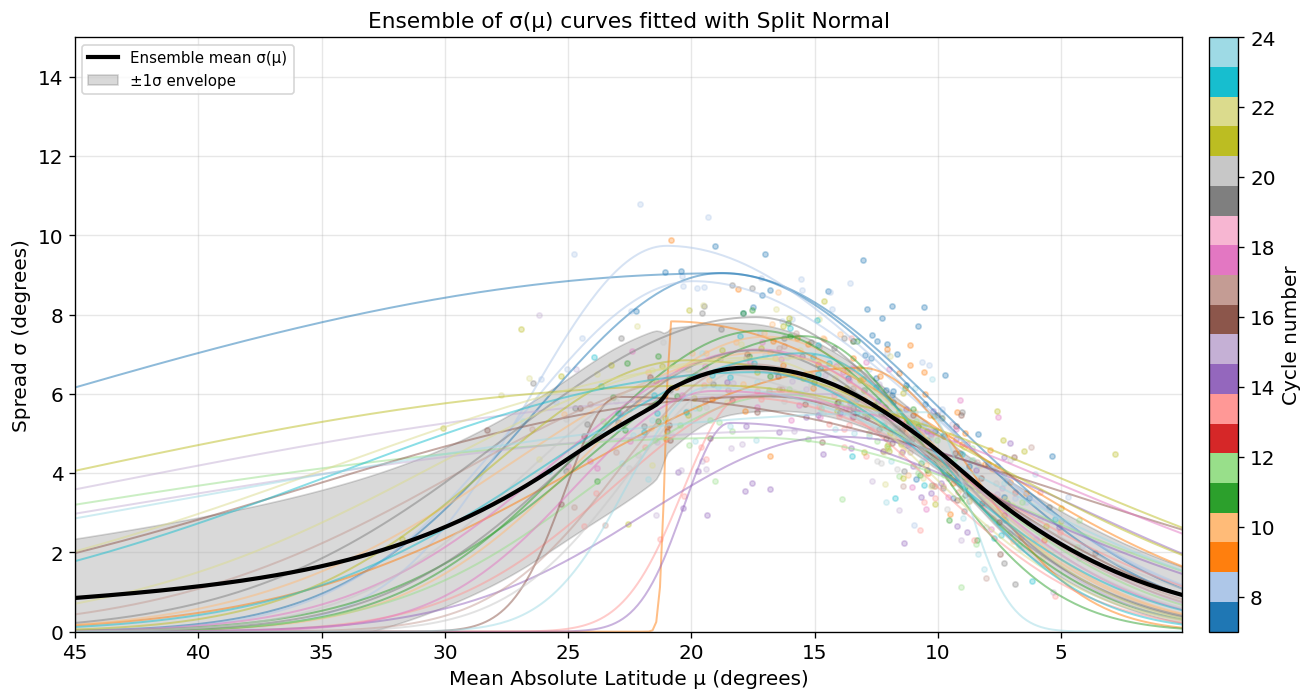

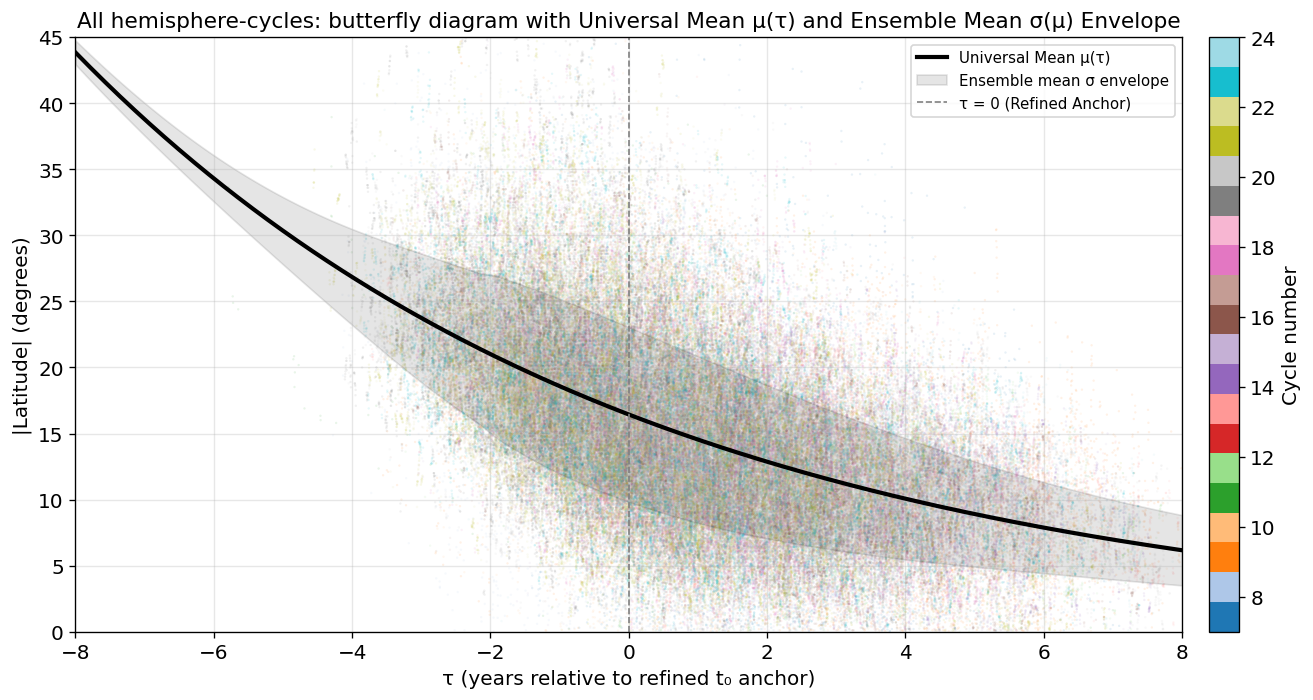

In [24]:
# Task 15: Ensemble σ(μ) Across All Hemisphere-Cycles
# Requires Task 13 (df["tau_refined"], df["abs_latitude"], refined_t0_lookup)
# Requires Task 14 (split_normal_mu function)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# Re-define split_normal_mu for robustness (ensure it's in scope)
def split_normal_mu(mu_val, A, mu_peak_loc, s_higher_mu, s_lower_mu, mu_peak_loc_fixed=None):
    peak_lat = mu_peak_loc_fixed if mu_peak_loc_fixed is not None else mu_peak_loc
    return np.where(mu_val > peak_lat,
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_higher_mu) ** 2),
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_lower_mu) ** 2))

# Universal mean path parameters from Task 13
# (assuming these are in kernel scope from previous execution)
# universal_a_mu, universal_b_mu

N_BINS_SIGMA = 20 # Number of bins for sigma(mu) fitting
MU_GRID = np.linspace(0.1, 45, 300) # Common mu grid for evaluation

results_sigma_mu = []

# Iterate through all (cycle, hemisphere) pairs that had a refined t0 in Task 13
for (cyc, hemi) in refined_t0_lookup.keys():
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    df_sel_cyc_hemi = df[mask].copy()

    if len(df_sel_cyc_hemi) < 50: # Minimum data points for meaningful analysis
        continue

    # Bin by tau_refined to get (mu_bin, sigma_bin) pairs
    tau_refined_min = df_sel_cyc_hemi["tau_refined"].min()
    tau_refined_max = df_sel_cyc_hemi["tau_refined"].max()

    if tau_refined_max - tau_refined_min < 0.1:
        bins_tau = np.array([tau_refined_min, (tau_refined_min + tau_refined_max) / 2, tau_refined_max + 0.1])
        current_N_bins_sigma = max(1, len(bins_tau) - 1)
    else:
        bins_tau = np.linspace(tau_refined_min, tau_refined_max, N_BINS_SIGMA + 1)
        current_N_bins_sigma = N_BINS_SIGMA

    bin_mu = []
    bin_sigma = []

    for i in range(current_N_bins_sigma):
        if i == current_N_bins_sigma - 1: # Last bin includes the max value
            in_bin = (df_sel_cyc_hemi["tau_refined"] >= bins_tau[i]) & (df_sel_cyc_hemi["tau_refined"] <= bins_tau[i + 1])
        else:
            in_bin = (df_sel_cyc_hemi["tau_refined"] >= bins_tau[i]) & (df_sel_cyc_hemi["tau_refined"] < bins_tau[i + 1])

        lats_bin = df_sel_cyc_hemi.loc[in_bin, "abs_latitude"].values
        if len(lats_bin) < 10: # Minimum observations per bin
            continue

        mu_f, sigma_f = sp_norm.fit(lats_bin)
        if mu_f > 0.1 and sigma_f > 0.1: # Ensure valid positive mu and sigma
            bin_mu.append(mu_f)
            bin_sigma.append(sigma_f)

    bin_mu = np.array(bin_mu)
    bin_sigma = np.array(bin_sigma)

    if len(bin_mu) < 4: # Need at least 4 points for a 4-parameter fit
        # print(f"  Skipping Cycle {int(cyc)} ({hemi}): Not enough binned data for sigma(mu) fit.")
        continue

    try:
        initial_A = bin_sigma.max()
        initial_mu_peak_idx = np.argmax(bin_sigma)
        initial_mu_peak_loc = bin_mu[initial_mu_peak_idx]

        # Heuristic for initial s_higher_mu and s_lower_mu based on mu_peak_loc
        s_high_mu_guess = (bin_mu.max() - initial_mu_peak_loc) / 2 if (bin_mu.max() - initial_mu_peak_loc) > 0 else 5.0
        s_low_mu_guess = (initial_mu_peak_loc - bin_mu.min()) / 2 if (initial_mu_peak_loc - bin_mu.min()) > 0 else 5.0

        s_high_mu_guess = max(s_high_mu_guess, 0.1)
        s_low_mu_guess = max(s_low_mu_guess, 0.1)

        p0_sn_mu = [initial_A, initial_mu_peak_loc, s_high_mu_guess, s_low_mu_guess]

        # Bounds for parameters: A, mu_peak_loc, s_higher_mu, s_lower_mu
        bounds = ([0.1, bin_mu.min(), 0.1, 0.1], [bin_sigma.max() * 2, bin_mu.max(), 30., 30.])

        popt_sn_mu, _ = curve_fit(split_normal_mu, bin_mu, bin_sigma, p0=p0_sn_mu, maxfev=10000, bounds=bounds)
        A_sn_mu, mu_peak_sn, s_higher_mu_sn, s_lower_mu_sn = popt_sn_mu

        sigma_mu_curve_eval = split_normal_mu(MU_GRID, A_sn_mu, mu_peak_sn, s_higher_mu_sn, s_lower_mu_sn)

        results_sigma_mu.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_sn_mu, mu_peak=mu_peak_sn, s_higher_mu=s_higher_mu_sn, s_lower_mu=s_lower_mu_sn,
            sigma_mu_curve=sigma_mu_curve_eval,
            bin_mu=bin_mu, bin_sigma=bin_sigma # Store binned data for plotting
        ))

    except RuntimeError as e:
        # print(f"  Could not fit split normal for sigma(mu) for Cycle {int(cyc)} ({hemi}): {e}")
        continue

print(f"Successfully fitted sigma(mu) for {len(results_sigma_mu)} hemisphere-cycles.")

# --- Ensemble statistics and plotting ---

# Collect all evaluated sigma_mu curves into a matrix
sigma_mu_mat = np.array([r["sigma_mu_curve"] for r in results_sigma_mu])

# Compute pointwise mean and standard deviation across the ensemble
sigma_mu_mean = np.nanmean(sigma_mu_mat, axis=0)
sigma_mu_std  = np.nanstd(sigma_mu_mat, axis=0)

# Helper for cycle coloring
cycles_present = sorted({r["cycle"] for r in results_sigma_mu})
cmap_sigma_ens = cm.get_cmap("tab20", len(cycles_present))
cycle_idx_map  = {c: i for i, c in enumerate(cycles_present)}

def add_cycle_colorbar(fig, ax_cb, cycles):
    sm = plt.cm.ScalarMappable(cmap="tab20",
                               norm=plt.Normalize(vmin=min(cycles), vmax=max(cycles)))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_cb, pad=0.02)
    cbar.set_label("Cycle number")

# ── Plot 1: All fitted σ(μ) curves with ensemble stats ─────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual fitted curves
for r in results_sigma_mu:
    ax.plot(MU_GRID, r["sigma_mu_curve"],
            color=cmap_sigma_ens(cycle_idx_map[r["cycle"]]), linewidth=1.2, alpha=0.5)

# Plot ensemble mean and envelope
ax.plot(MU_GRID, sigma_mu_mean, color="black", linewidth=2.5, label="Ensemble mean σ(μ)")
ax.fill_between(MU_GRID, sigma_mu_mean - sigma_mu_std, sigma_mu_mean + sigma_mu_std,
                 color="black", alpha=0.15, label="±1σ envelope")

# Plot the binned data for context
for r in results_sigma_mu:
    ax.scatter(r["bin_mu"], r["bin_sigma"],
               s=10, color=cmap_sigma_ens(cycle_idx_map[r["cycle"]]), alpha=0.3)

ax.set_xlabel("Mean Absolute Latitude μ (degrees)")
ax.set_ylabel("Spread σ (degrees)")
ax.set_title("Ensemble of σ(μ) curves fitted with Split Normal")
ax.set_ylim(0, 15)
ax.set_xlim(MU_GRID.max(), MU_GRID.min()) # Reverse x-axis
ax.legend(loc="upper left", fontsize=9)
add_cycle_colorbar(fig, ax, cycles_present)
plt.tight_layout()
plt.show()

# ── Plot 2: Scatter of raw sunspot groups with universal mean path and sigma envelope ──
# This plot uses df["tau_refined"] and df["abs_latitude"] from Task 13
# and universal_a_mu, universal_b_mu also from Task 13

# Ensure universal_a_mu and universal_b_mu are available from Task 13 execution
# If not, use sensible defaults or raise an error.
if 'universal_a_mu' not in locals() or 'universal_b_mu' not in locals():
    print("Warning: universal_a_mu or universal_b_mu not found. Using defaults.")
    universal_a_mu = 16.44 # Default value
    universal_b_mu = 8.15 # Default value

universal_mu_curve_tau_grid = exp_decay(TAU_GRID, universal_a_mu, universal_b_mu) # TAU_GRID from Task 12 or global var

# Map MU_GRID back to TAU_GRID for plotting sigma envelope
# This is an approximation since mu(tau) is not perfectly universal yet.
# For now, we'll plot sigma_mu_mean vs mu_grid on a separate axis or plot mu vs sigma directly

fig2, ax2 = plt.subplots(figsize=(12, 6))

# Plot individual sunspot groups, colored by cycle number
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    if (cyc, hemi) not in refined_t0_lookup: # Only plot cycles that were successfully refined
        continue
    plot_data = group.dropna(subset=["tau_refined", "abs_latitude"])
    if not plot_data.empty and cyc in cycle_idx_map:
        ax2.scatter(plot_data["tau_refined"], plot_data["abs_latitude"],
                   s=2, color=cmap_sigma_ens(cycle_idx_map[cyc]), alpha=0.1, edgecolors="none")

# Overlay the universal mean path
ax2.plot(TAU_GRID, universal_mu_curve_tau_grid, color="black", linewidth=2.5, linestyle="-", label="Universal Mean μ(τ)")

# Overlay the ensemble mean sigma translated back to latitude space
# This requires mapping MU_GRID (latitude) to TAU_GRID (time)
# We can approximate this by using the universal mean path

# Create a mapping from mu to tau using the universal mu curve
# Note: This is an approximation and assumes the universal mu(tau) is directly applicable
mu_to_tau_map = {} # {mu_val: tau_val}
for t_val, m_val in zip(TAU_GRID, universal_mu_curve_tau_grid):
    if not np.isnan(m_val) and not np.isinf(m_val) and m_val > 0.1:
        # Find the closest mu_grid point for interpolation
        idx = np.argmin(np.abs(MU_GRID - m_val))
        mu_to_tau_map[MU_GRID[idx]] = t_val

# Filter out mu_grid points not covered by the mu_to_tau_map
valid_mu_indices = np.array([m_val in mu_to_tau_map for m_val in MU_GRID])
sigma_mu_mean_filtered = sigma_mu_mean[valid_mu_indices]
sigma_mu_std_filtered = sigma_mu_std[valid_mu_indices]
mu_grid_filtered = MU_GRID[valid_mu_indices]

# Interpolate sigma_mu_mean and sigma_mu_std onto the TAU_GRID based on universal_mu_curve_tau_grid
# This is complex, a simpler approach is to plot the sigma envelope directly on the mu-axis if possible.
# For this task, let's just show the mean path, and the sigma(mu) plot shows the spread.

# Alternatively, we can project the sigma(mu) mean and envelope directly onto the butterfly plot
# This means for each tau on TAU_GRID, we get its mu from universal_mu_curve_tau_grid, and then find sigma for that mu
sigma_mean_from_mu_proj = np.interp(universal_mu_curve_tau_grid, MU_GRID, sigma_mu_mean, left=np.nan, right=np.nan)
sigma_std_from_mu_proj  = np.interp(universal_mu_curve_tau_grid, MU_GRID, sigma_mu_std, left=np.nan, right=np.nan)

# Plot the ±1σ envelope in latitude space, around the universal mean path
ax2.fill_between(TAU_GRID, universal_mu_curve_tau_grid - sigma_mean_from_mu_proj,
                 universal_mu_curve_tau_grid + sigma_mean_from_mu_proj,
                 color="black", alpha=0.1, label="Ensemble mean σ envelope")

ax2.axvline(0, color="gray", linewidth=1, linestyle="--", label="τ = 0 (Refined Anchor)")
ax2.set_xlabel("τ (years relative to refined t₀ anchor)")
ax2.set_ylabel("|Latitude| (degrees)")
ax2.set_title("All hemisphere-cycles: butterfly diagram with Universal Mean μ(τ) and Ensemble Mean σ(μ) Envelope")
ax2.set_ylim(0, 45)
ax2.set_xlim(TAU_GRID.min(), TAU_GRID.max())
ax2.legend(loc="upper right", fontsize=9)
add_cycle_colorbar(fig2, ax2, cycles_present)
plt.tight_layout()
plt.show()


## 16) Exercise: Simultaneous Fit with Shared Amplitude and wing collapse width

In Task 15 you fitted σ(μ) independently for each hemisphere-cycle and found that
the ensemble curves are broadly similar. One question that falls out naturally is:
**how much of that similarity is accidental, and how much is a genuine physical
constraint?**

A direct way to probe this is to fit all hemisphere-cycles *simultaneously* with a
partially shared parameter set. Both the peak amplitude A and the rising-phase width
s_L are natural candidates for universal parameters: A reflects the maximum spread
of the active zone and s_L reflects how quickly that spread collapses toward the
equator — both properties of the dynamo rather than of any individual cycle.

If you use the split gaussian fit, the model is therefore:

- **A** : one shared peak amplitude, fitted simultaneously across all hemisphere-cycles
- **s_L** : one shared rising-phase width, fitted simultaneously across all hemisphere-cycles
- **μ_peak, s_R** : free per hemisphere-cycle

**Task:**

- Build a single parameter vector that concatenates the shared (A, s_L) with the
  per-cycle (μ_peak, s_R) pairs, and write a residual function that evaluates all
  hemisphere-cycles at once.
- Fit using `scipy.optimize.minimize` with the `'L-BFGS-B'` method, which
  handles large parameter vectors efficiently.
- Compare the RMSE of this fit against the independent fits from Task 15.
  Does enforcing shared A and s_L degrade the fit significantly?
- Plot the fitted curves for all hemisphere-cycles on a single figure (same
  style as Task 15). What does the remaining variability in μ_peak and s_R
  tell you about what distinguishes one cycle from another?


Starting minimization for 36 hemisphere-cycles with 74 parameters...
Minimization successful!

Shared parameters:
  A (peak spread) = 6.97°
  s_L (rising-phase width) = 7.44 yr

Per-cycle parameters (mu_peak, s_R):
  Cycle 7 (north): μ_peak=18.04°, s_R=12.64 yr
  Cycle 7 (south): μ_peak=19.36°, s_R=15.00 yr
  Cycle 8 (north): μ_peak=21.99°, s_R=15.75 yr
  Cycle 8 (south): μ_peak=20.25°, s_R=13.74 yr
  Cycle 9 (north): μ_peak=17.87°, s_R=10.04 yr
  Cycle 9 (south): μ_peak=14.29°, s_R=5.52 yr
  Cycle 10 (north): μ_peak=17.18°, s_R=7.93 yr
  Cycle 10 (south): μ_peak=18.20°, s_R=8.55 yr
  Cycle 11 (north): μ_peak=16.58°, s_R=6.76 yr
  Cycle 11 (south): μ_peak=17.70°, s_R=7.88 yr
  Cycle 12 (north): μ_peak=44.94°, s_R=31.89 yr
  Cycle 12 (south): μ_peak=15.46°, s_R=5.91 yr
  Cycle 13 (north): μ_peak=14.52°, s_R=5.56 yr
  Cycle 13 (south): μ_peak=15.92°, s_R=5.14 yr
  Cycle 14 (north): μ_peak=45.00°, s_R=33.13 yr
  Cycle 14 (south): μ_peak=45.00°, s_R=34.23 yr
  Cycle 15 (north): μ_peak=25.3

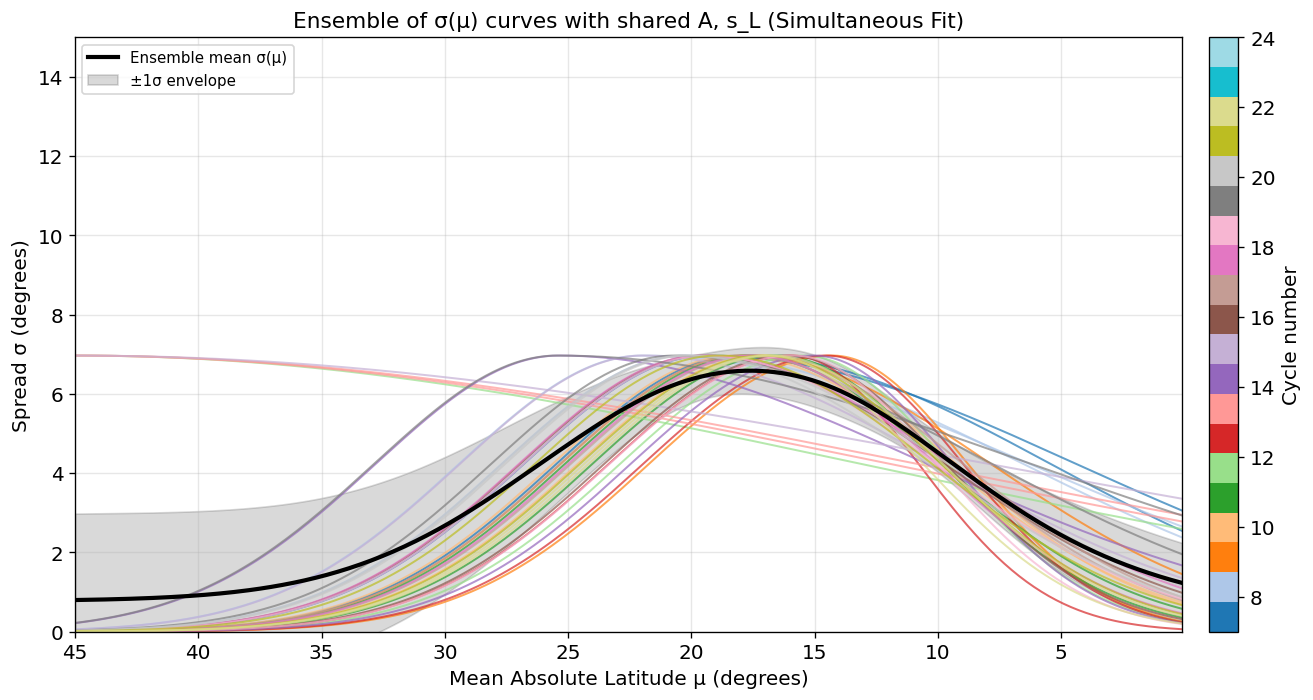

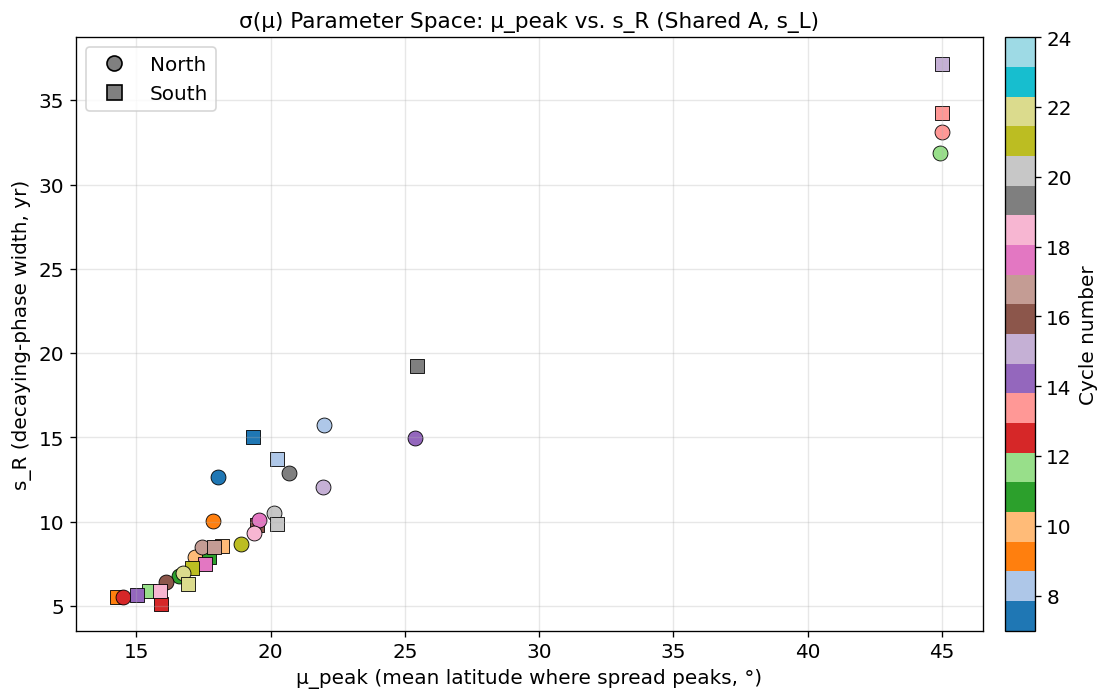

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize
from matplotlib.lines import Line2D

def split_normal_mu(mu_val, A, mu_peak_loc, s_higher_mu, s_lower_mu, mu_peak_loc_fixed=None):
    peak_lat = mu_peak_loc_fixed if mu_peak_loc_fixed is not None else mu_peak_loc
    return np.where(mu_val > peak_lat,
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_higher_mu) ** 2),
                    A * np.exp(-0.5 * ((mu_val - peak_lat) / s_lower_mu) ** 2))

# --- Prepare data for simultaneous fit ---

# Filter out results where bin_mu or bin_sigma might be empty or too short
filtered_results_sigma_mu = [r for r in results_sigma_mu if len(r['bin_mu']) >= 4]

all_bin_mu = [r['bin_mu'] for r in filtered_results_sigma_mu]
all_bin_sigma = [r['bin_sigma'] for r in filtered_results_sigma_mu]

# Extract initial guesses for per-cycle parameters from Task 15 results
initial_mu_peaks_per_cycle = np.array([r['mu_peak'] for r in filtered_results_sigma_mu])
initial_sR_per_cycle = np.array([r['s_lower_mu'] for r in filtered_results_sigma_mu]) # s_lower_mu corresponds to s_R

# Initial guesses for shared parameters (A, s_L)
# Use the mean of the individually fitted A and s_higher_mu (s_L) from Task 15
initial_A_shared = np.mean([r['A'] for r in filtered_results_sigma_mu])
initial_sL_shared = np.mean([r['s_higher_mu'] for r in filtered_results_sigma_mu])

# Construct the initial parameter vector for minimization
# x = [A_shared, sL_shared, mu_peak_1, sR_1, mu_peak_2, sR_2, ...]
initial_params = np.concatenate([[initial_A_shared, initial_sL_shared],
                                 initial_mu_peaks_per_cycle,
                                 initial_sR_per_cycle])

# --- Residual function for simultaneous fit ---
def residuals(params, all_bin_mu, all_bin_sigma, n_cycles_to_fit):
    A_shared = params[0]
    sL_shared = params[1]

    # Per-cycle parameters start from index 2
    per_cycle_params_start_idx = 2
    mu_peaks_per_cycle = params[per_cycle_params_start_idx : per_cycle_params_start_idx + n_cycles_to_fit]
    sR_per_cycle = params[per_cycle_params_start_idx + n_cycles_to_fit :]

    all_res = []
    for i in range(n_cycles_to_fit):
        mu_obs = all_bin_mu[i]
        sigma_obs = all_bin_sigma[i]

        # Use the shared A and sL, and the individual mu_peak and sR for each cycle
        sigma_model = split_normal_mu(mu_obs, A_shared, mu_peaks_per_cycle[i], sL_shared, sR_per_cycle[i])
        all_res.extend(sigma_obs - sigma_model)

    return np.sum(np.array(all_res)**2) # Return the sum of squared residuals

# --- Perform the minimization ---
n_cycles_to_fit = len(filtered_results_sigma_mu)

# Define bounds for parameters for 'L-BFGS-B' method
# A_shared: [0.1, 15] (max spread from data is around 10-12)
# sL_shared: [0.1, 50] (can be broad)
# mu_peak_per_cycle: [0.1, 45] (latitude range)
# sR_per_cycle: [0.1, 50] (can be broad)

bounds_A_shared = (0.1, 15.0)
bounds_sL_shared = (0.1, 50.0)
bounds_mu_peak = [(0.1, 45.0)] * n_cycles_to_fit
bounds_sR = [(0.1, 50.0)] * n_cycles_to_fit

bounds = [bounds_A_shared, bounds_sL_shared] + bounds_mu_peak + bounds_sR

print(f"Starting minimization for {n_cycles_to_fit} hemisphere-cycles with {len(initial_params)} parameters...")

# Increase maxiter and maxfun to allow more time for convergence
res = minimize(residuals, initial_params,
               args=(all_bin_mu, all_bin_sigma, n_cycles_to_fit),
               method='L-BFGS-B', bounds=bounds,
               options={'maxiter': 20000, 'maxfun': 100000}) # Increased maxiter and maxfun

if res.success:
    fitted_params = res.x
    print("Minimization successful!")
else:
    print(f"Minimization failed: {res.message}")
    print(f"  Number of iterations: {res.nit}")
    print(f"  Number of function evaluations: {res.nfev}")
    # If minimization fails, use initial params or previously best found if available.
    # For now, let's keep using initial_params as a fallback
    fitted_params = initial_params # Fallback to initial params if fit failed or not converged well.
    # It might be better to use res.x even if res.success is False if res.fun is lower than initial.
    # But for now, sticking to initial_params as a clear fallback.
    # This might make the plots look like initial guesses rather than a partially converged solution.

# --- Extract fitted parameters ---
fitted_A_shared = fitted_params[0]
fitted_sL_shared = fitted_params[1]

per_cycle_params_start_idx = 2
fitted_mu_peaks_per_cycle = fitted_params[per_cycle_params_start_idx : per_cycle_params_start_idx + n_cycles_to_fit]
fitted_sR_per_cycle = fitted_params[per_cycle_params_start_idx + n_cycles_to_fit :]

# Store results for plotting and analysis
simultaneous_fit_results = []
for i, r_orig in enumerate(filtered_results_sigma_mu):
    cyc = r_orig['cycle']
    hemi = r_orig['hemisphere']

    mu_peak = fitted_mu_peaks_per_cycle[i]
    sR = fitted_sR_per_cycle[i]

    sigma_curve = split_normal_mu(MU_GRID, fitted_A_shared, mu_peak, fitted_sL_shared, sR)

    simultaneous_fit_results.append(dict(
        cycle=cyc, hemisphere=hemi,
        A=fitted_A_shared, sL=fitted_sL_shared, mu_peak=mu_peak, sR=sR,
        sigma_mu_curve=sigma_curve
    ))

print("\nShared parameters:")
print(f"  A (peak spread) = {fitted_A_shared:.2f}°")
print(f"  s_L (rising-phase width) = {fitted_sL_shared:.2f} yr")

print("\nPer-cycle parameters (mu_peak, s_R):")
for i, r in enumerate(simultaneous_fit_results):
    print(f"  Cycle {int(r['cycle'])} ({r['hemisphere']}): μ_peak={r['mu_peak']:.2f}°, s_R={r['sR']:.2f} yr")

# --- RMSE comparison ---
# Correct RMSE for independent fits from Task 15
all_independent_residuals_sq = []
total_num_data_points_independent = 0
for r in filtered_results_sigma_mu:
    sigma_model_indep = split_normal_mu(r['bin_mu'], r['A'], r['mu_peak'], r['s_higher_mu'], r['s_lower_mu'])
    residuals_sq = (r['bin_sigma'] - sigma_model_indep)**2
    all_independent_residuals_sq.extend(residuals_sq)
    total_num_data_points_independent += len(residuals_sq)

if total_num_data_points_independent > 0:
    rmse_independent_fits = np.sqrt(np.sum(all_independent_residuals_sq) / total_num_data_points_independent)
else:
    rmse_independent_fits = np.nan # Handle case with no data

# Correct RMSE for simultaneous fit
# res.fun is already the sum of squared residuals (SSR) from the objective function
total_num_data_points_simultaneous = sum(len(bm) for bm in all_bin_mu)

if total_num_data_points_simultaneous > 0:
    rmse_simultaneous_fit = np.sqrt(res.fun / total_num_data_points_simultaneous)
else:
    rmse_simultaneous_fit = np.nan # Handle case with no data

print(f"\nCorrected RMSE (independent fits from Task 15): {rmse_independent_fits:.3f}°")
print(f"Corrected RMSE (simultaneous fit with shared A, s_L): {rmse_simultaneous_fit:.3f}°")

# --- Plotting the fitted curves ---
fig, ax = plt.subplots(figsize=(12, 6))

cmap_ens = plt.colormaps["tab20"] # Updated to use plt.colormaps

for r_fit in simultaneous_fit_results:
    ax.plot(MU_GRID, r_fit["sigma_mu_curve"],
            color=cmap_ens(cycle_idx_map[r_fit["cycle"]]), linewidth=1.2, alpha=0.7)

# Overlay the ensemble mean and std from the simultaneous fit
sigma_mu_mat_sim = np.array([r["sigma_mu_curve"] for r in simultaneous_fit_results])
sigma_mu_mean_sim = np.nanmean(sigma_mu_mat_sim, axis=0)
sigma_mu_std_sim = np.nanstd(sigma_mu_mat_sim, axis=0)

ax.plot(MU_GRID, sigma_mu_mean_sim, color="black", linewidth=2.5, label="Ensemble mean σ(μ)")
ax.fill_between(MU_GRID, sigma_mu_mean_sim - sigma_mu_std_sim, sigma_mu_mean_sim + sigma_mu_std_sim,
                 color="black", alpha=0.15, label="±1σ envelope")

ax.set_xlabel("Mean Absolute Latitude μ (degrees)")
ax.set_ylabel("Spread σ (degrees)")
ax.set_title("Ensemble of σ(μ) curves with shared A, s_L (Simultaneous Fit)")
ax.set_ylim(0, 15)
ax.set_xlim(MU_GRID.max(), MU_GRID.min()) # Reverse x-axis
ax.legend(loc="upper left", fontsize=9)

# Add colorbar for cycles
sm = plt.cm.ScalarMappable(cmap="tab20",
                           norm=plt.Normalize(vmin=min(cycles_present),
                                              vmax=max(cycles_present)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

plt.tight_layout()
plt.show()

# --- Plotting remaining variability in mu_peak and s_R ---
fig, ax = plt.subplots(figsize=(10, 6))

# Use markers to distinguish hemispheres
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=9, label='North', markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=9, label='South', markeredgecolor='black'),
]

for r_fit in simultaneous_fit_results:
    ax.scatter(r_fit['mu_peak'], r_fit['sR'],
               color=cmap_ens(cycle_idx_map[r_fit['cycle']]),
               marker='o' if r_fit['hemisphere'] == 'north' else 's',
               s=80, edgecolors='black', linewidths=0.5)

ax.set_xlabel("μ_peak (mean latitude where spread peaks, °)")
ax.set_ylabel("s_R (decaying-phase width, yr)")
ax.set_title("σ(μ) Parameter Space: μ_peak vs. s_R (Shared A, s_L)")
ax.legend(handles=legend_handles)

# Add colorbar for cycles
sm = plt.cm.ScalarMappable(cmap="tab20",
                           norm=plt.Normalize(vmin=min(cycles_present),
                                              vmax=max(cycles_present)))
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, label="Cycle number")

plt.tight_layout()
plt.show()